# Contents:  

Angular behavior of $p_z$ orbital  
Author name  
Some conceptual frameworks  
Required reading  
Preface  
Introduction  
Figure of the Schr$\ddot{o}$dinger equation and Harmonic Oscillator  
Diagnostic  
Zero has no multiplicative inverse  
Warning  
$\mathbb Q$ numbers  
Figure of Binary entropy diagram  
Definitions  
Figure of Anharmonic vs Simple Harmonic Oscillator  
Ideas that work  
Common nomenclature  
 Familiar, recognized, and understood equations  
Physics of the Universe(Manifolds of paring maps, on  self adjoint subspaces)  
Figure of relativistic mass increase  
A few constants  
Useful formulea  
Some practice, and other useful formulae  
   Figure of Breit-Wigner Distribution  
Test your comprehension  
Appendix  
    Periodic table of chemical elements generator  
    List of experiments  
References  


##
    
    
    

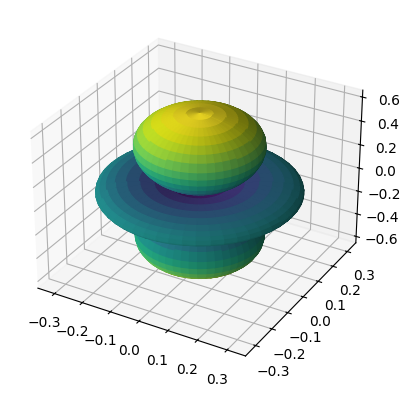

In [1]:
import numpy as np
from scipy.special import sph_harm_y
import matplotlib.pyplot as plt

# 1. Define Quantum Numbers
l = 2  # Degree (angular momentum)
m = 0  # Order

# 2. Create Grid (theta=polar, phi=azimuthal)
theta = np.linspace(0, np.pi, 100)
phi = np.linspace(0, 2 * np.pi, 100)
theta, phi = np.meshgrid(theta, phi)

# 3. Calculate Spherical Harmonic Y_l,m(theta, phi)
# Note: scipy.special.sph_harm_y uses order (m, n, theta, phi)
# but updated signatures often accept (n, m, theta, phi)
# The order here is crucial.
Y = sph_harm_y(l, m, theta, phi)

# 4. Plotting the angular part (absolute value)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# Convert angular part (complex) to radius (real)
radius = np.abs(Y)
x = radius * np.sin(theta) * np.cos(phi)
y = radius * np.sin(theta) * np.sin(phi)
z = radius * np.cos(theta)

ax.plot_surface(x, y, z, facecolors=plt.cm.viridis(radius / radius.max()))
plt.show()

# Quantum Mechanics(very basic) with magnetic deflection, core notes(Theory, barely descriptive)  

## Author: Owino Steve  

### Date: March 22, 2026



# Some Conceptual Frameworks(The names in color are Nobel prize receipients, and nomenees).

$\bullet$ Copenhagen interpretation(s) - $\color{blue}{\text{Bohr, Heisenberg, Pauli}}$, von Weis$\ddot{a}$cker, $\color{blue}{\text{Peierls}}$.  

$\bullet$ Non-local Hidden Variables - $\color{blue}{\text{de Broglie}}$, Bohm, Maudlin, Goldstein, Hardy.  

$\bullet$ Convival Solipism - Zwirn  

$\bullet$ Modal Interpretations - Kochen, Dieks, van Fraassen, Bub, Sipe.  

$\bullet$ Conscienceness-induced Collapse - $\color{blue}{\text{Wigner}}$, von Neumann, $\color{blue}{\text{Josephson}}$.  

$\bullet$ Objective Collapse Models - Ghiradi-Rimini-Weber, Pearl, $\color{blue}{\text{Penrose}}$, Tumulka.  

$\bullet$ Consistent/Decoherent Histories - Griffiths, Omn$\acute{e}$s, $\color{blue}{\text{Gell-Mann}}$, Hartle.  

$\bullet$ Superdeterminsm - $\color{blue}{\text{t'Hooft}}$, Hossenfelder.  
                                                
$\bullet$ Rational Interpretations - Rovelli
                                                
$\bullet$ Ensemble Interpretations - Ballentine, $\color{blue}{\text{Einstein}}$  
                                                
$\bullet$ Informational Interpretation - $\color{blue}{\text{Zellinger}}$, Brukner, Bulb.  
                                                
$\bullet$ Many-Worlds Interpretation - Everett, Hawking, Science-fiction fans.

##
                                                

# Required reading:  
Spectrum of the harmonic oscillator  
Spectral Theorem  
Linear Algebra(particularly Matrix Theory)  
Continous Functional Calculus(systems of 2nd order differential equations for vector-valued functions, and factoring)  
Measure Theory  
Equipartition theorem(law of equipartition of energy)  
Electromagnetic theory of light.

# Preface

Abstract Mathematics(models of inductive reasoning), is availed to avoid nonsensical answers, and bogus non-differentiable functions. This is the task for the human mind; to see this truth, and preserve it.
It's accepted that the angular momentum of a closed system is conserved(hence production of particles by conversion of gravitational energy into matter energy, conditioned by Biological factors). The origin of the universe(a Physical picture of a polarizable space, and characterized as young by $\frac{\epsilon} {\epsilon_0}$ ~1, with an energy density when expressed in Newtonian units), is not a reproducible event, and cannot be duplicated in the laboratory. In trying to eliminate the Riemann curvature tensor, there's also the Ricci curvature tensor, assuming the photon travels without a shift in energy or frequency(red shift). There are formidable problems facing String Theory: it has no predictive power, it's a highly sophisticated theoretical laboratory(rather than experimental), it's defined at the Planck energy($10^{19}$ GeV), as any Physical theory that you can possibly come up with, it cannot be tested with the present technology, and it's tightly constrained as much as the graviton emerges as a massless state with spin-2.
Space-time is beyond being verified experimentally, and of the vacua states, only one is needed to be isolated, and the  Cosmological constant is very close to 0. However, in this theory, when there's spontaneous symmetry breaking, one does not know how to keep the Cosmological constant 0, perhaps a solution will be found to isolate the one vacuum.
<a id='plot'></a>
No space/time for boredom! Have fun, and ask a Physics lab fundamental questions.  
<a id='plot'></a>  
The letters in bold transform like vectors! Notebook is parsing on jupyter notebook/lab, Colab,  and ipynb viewer(Android).  
<a id='plot'></a>  
These are notes/references, 1% functional code! 
<a id='plot'></a>  


An electron plays a central role, and can be assumed to move in a spherically symmetric field, where all binding energies are negative. These are advanced core notes(reference sheet) in Quantum Mechanics(describing how particles behave like waves - 
the state of a given system[internal structure], and its' probabilities), 
and some equations of Mathematical Physics[some theorems are mentioned to emphasize the concept of unitarity].
The key important formulas are the Schr$\ddot{o}$dinger equation, 
Uncertainty Principle, energy levels of the hydrogen atom, harmonic oscillator energy,
and the Hamiltonian energy(of which describes how a system evolves in time). 
Included, are physical quantities, long expressions, Gauge Theory, 
important systems(like the Harmonic Oscillator, the energy levels of the Hydrogen atom), Mathematical tools, 
important inequalities, and some advanced notes on Quantum Field Theory. The multiplication by $i$ makes it possible
to carry over to QM(Quantum Mechanics)...this is one of the most striking features of Classical Mechanics(CM)-namely,
the correspondence between observables, and one-parameter groups of symmetries. We hereby have a Mathematical model
capable in principle, of supplying the answer to any Physical question we might ask. The fact that the eigenvalues check with
the observed spectrum of the hydrogen atom, when one takes $\mathbf K$ = $\frac{\hbar}{2 \pi}$, which provides a confirmation
of the identity of $\hbar$, with $\frac{\hbar}{2 \pi}$. Your objective, dear reader, is to show in theorems of analysis, providing
asymptotic formulas for the eigenvalue distribution of differential operators.                                                                      
Don't try to read these notes linearly, instead, come back here as a formula reference.  
NOTE: Elementary logic functions(Boolean gates)/Disjuctive Normal Forms, Computation complexities, Algorithms, and Quantum circuits, are not part of this material.                                                                   


## Introduction
There is NO electronic ink for philosophical arguments! i.e. local realism does not exist, 
how long will $\mathbb Z$ remain a bachelor, cold fusion, climate change, singularities, why wave-functions overlap, determinism, 
hidden variables(proof that subquantum level don't exist), why periodicity of quantum numbers lead to periodicity of chemical elements, quantum jumps, spin-flip transitions(oscillating magnetic monopoles/distance transverse magnetic $\mathbf B$ produced by an oscillating magnetic dipole, etc.... 
Ultra-cold atoms(lock-stepped with the same spin), 
have been realized in the laboratory(Bose-Einstein condensate[BEC]), 
through observing the center of mass system(a trick) of wave-like
properties of atoms, so that the Pauli exclusion principle is NOT violated. 
This technology, although limited(interaction with the external enviroment depolarizes particles) has applications
in quantum computers(cryptography - quantum key distribution), 
and is realized only for very low temperature Kelvin scales, not for classical computers. 
Even the speed of light (c) - has been stopped!, using slow light pulses. 
The wave-particle duality(using a super-computer) was proved by an experiment in 1974 by 
John Clauser( concludes that the wave-function collapse is an objective real process - not a physical process, 
and not relativistic invariant - agreed). The idea of measurement of the wavefunction with any apparatus(alters the azimuthal quantum number/angular momentum of the orbital plane - resulting to
a breakup of eigenvalues into a one-dimensional representation cylindrical symmetry of 2j + 1, from spherical symmetry of j.                  
Why, currently no answer/solutions...maybe its' even a wrong question. Considering Faradays' Law, knowing
the Fourier transform, invoke a linear and orthogonal tranformation to Stokes' theorem, generalizing how the electric field remain constant,
the magnetic field too(curl $\mathbf E$ = - $\frac{\partial \mathbf B}{\partial t})$, with $\iint_s \mathbf F dS$ = $\int_c \mathbf F dt$,
where C is a closed curve, and $\mathbf F$ is a vector field defined in C. It can be calculated by making the electric field constant, 
and varying the magnetic field e.g.
$\mathbf B(t)$ = $\langle tx, ty, -2tz \rangle$, $0<t<\infty$. Note that in general, the z component of angular momentum is $\hbar$m, with probability $\mathbb 1$, and m is the state of the magnetic quantum number.                 
This analysis is ficticiously true, and is based on accepting the theory of
of complex numbers, Maxwells' equation, Fourier transform, homogeneous linear differential equations, the double-slit
experiment(results on the screen is a transmitted split beam intensity profile), Stern-Gerlach experiment(represents an entangled magnetic moment of Silver atoms), and Schr$\ddot{o}$dingers' equation.
There are no visible sources of some forms though, they're(strange and arbitrary) shematic representation of  physical ideas(Force, momentum, energy, mass, work, acceleration. length of interval, time, and velocity)...are all approximations!
The simultaneous probability distributions of various observables, given differential equations, which may be integrated
show how these observables change in time.  
Keep in mind, we've evolved from thinking the Sun (a linear combination of a stationary state[not static], its' probablities don't change!! revolved around the Earth{a linear combination of a stationary state, with no changing probabilities), it's now the other way around.



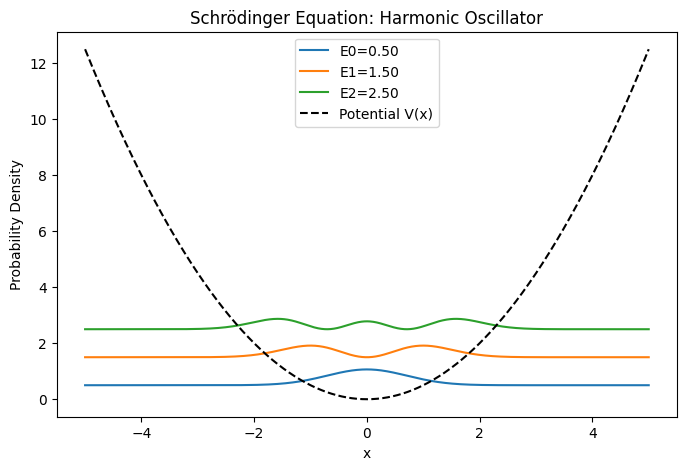

In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# 1. Setup Parameters
N = 1000  # Number of grid points
L = 10.0  # Domain size (-L/2 to L/2)
x = np.linspace(-L/2, L/2, N)
dx = x[1] - x[0]

# 2. Potential Energy (e.g., Harmonic Oscillator V = 0.5 * x^2)
V = 0.5 * x**2 

# 3. Hamiltonian Matrix Construction
# Kinetic Energy (Finite Difference Method)
# T = -0.5 * d^2/dx^2
D2 = (np.diag(-2 * np.ones(N)) + np.diag(np.ones(N-1), 1) + np.diag(np.ones(N-1), -1)) / dx**2
H = -0.5 * D2 + np.diag(V)

# 4. Solve the Eigenvalue Problem
energies, wavefunctions = la.eigh(H)

# 5. Plot the Results
plt.figure(figsize=(8,5))
for i in range(3): # Plot first 3 states
    # Normalize
    wf = wavefunctions[:, i] / np.sqrt(dx)
    plt.plot(x, wf**2 + energies[i], label=f'E{i}={energies[i]:.2f}')

plt.plot(x, V, 'k--', label='Potential V(x)')
plt.title('Schrödinger Equation: Harmonic Oscillator')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.show()


# Diagnostic

(a) If you can show that $y = 2x^2$ is a solution to the differential equation: $\frac{1}{2}x^2y''-xy'+y$ = 0,  

(b) If $y_1(t)$ = $e^{3t}$, and $y_2(t)$ = $e^{-3t}$ are solutions to $y'' - 9y$ = 0, what is the general solution? Note that $y_1$ and 
$y_2$ are NOT constant multiples of one another, so they are linearly independent. Thus the general solution in the differential equation is 
y(t) = $c_1e^{3t} + c_2e^{-3t}$,  

(c) If $y^{''} - 2y^{'} + 5y $= 0, has the associated characteristic equation $\lambda^2 - 2\lambda + 5$ = 0,
by the quadratic formula, the roots of the characteristic equation are 1$\pm 2{i}$. 
Therefore, the general solution to this differential equation is y(x) = $e^x(c_1cos2{x}+c_2sin2{x})$.  

NOTE: $\frac{\hbar}{i}$ = -i$\hbar$ (Multiplying by -i is the same as dividing by i.)                    
                     


PROCEED...

# Schrodinger Equation

$\bullet$ General linear homgeneous solution(from translation operators), to the time-dependent Schr$\ddot{o}$dinger Equation $\longrightarrow$ $\psi$(x,t) = $\sum_{n = 1}^\infty$ $C_n$ $\psi(x) e^{- \frac{i E t}{\hbar}}$, for t = 0; $C_n$ are constants.  
         
Integral form, time-dependent $\longrightarrow$ $\psi(x,t)$ = $\int \mathbf K[x,t:q_0,t_0]\psi(q_0,t_0)dx_0$, where  
$\mathbf K$ is the kernel/propagator.
    
    
    

# The identity Zero

Zero has no multiplicative inverse!!

# Informational Warning

<div class="alert alert-block alert-info">
⚠️ All descriptions here are in the literature, and not original. DO NOT attempt to frame a physical picture!!, or take relativity into sufficient account. Quantum Field Theory follows once these principles are mastered.  
</div>

# Note on Rational numbers

If (a) $\neq$ 0, there is no rational number($\mathbb Q$), where (b) $\times$ 0 = (a), can be fulfilled.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Probability p (0 to 1)
p = np.linspace(0.001, 0.999, 200)

# Binary Entropy Calculation: -p*log2(p) - (1-p)*log2(1-p)
entropy = -p * np.log2(p) - (1 - p) * np.log2(1 - p)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(p, entropy, label='Binary Entropy $H(p)$')
plt.title('Binary Entropy Diagram')
plt.xlabel('Probability $p$')
plt.ylabel('Entropy (bits)')
plt.grid(True)
plt.axvline(0.5, color='red', linestyle='--', label='Max Entropy at p=0.5')
plt.legend()
plt.show()

# Definitions  
Quantum Theory - a generalization/systematic refinement of classical mechanics  
Quantum communication/computation $\longrightarrow$ Manipulating qubits with quantum gates; Qubits being transmitted between different parties; Exploring applications based on sending information, rather than processing it.  
Quantum Fourier Transform $\longrightarrow$ $\phi$ = $\sum_{k = 0}^{n - 1}$ $y_k$|k> = $\frac{1}{\sqrt 2}$ $\sum_{k = 0}^{n - 1}$ $e^{ \frac{2 \pi {ijk}}{N}}$|k> = $\frac{1}{\sqrt 2}$ $\sum_{k = 0}^{N - 1}$ $\omega^{jk}$|k> for N = 2, and k = 0,1. (Note $\omega$ = $e^{\frac{2 \pi}{N}}$)  
An entangled pair $\longrightarrow$ Applying one qubit by manipulating the larger set of the four possible states.  
Von Neumann entropy $\longrightarrow$ S($\rho$) = - tr($\rho \ln \rho$) = - $\sum_j \lambda_j \ln \lambda_j$(These are diagonalized values); $S(\rho)$ = 0 $\iff$ $\rho^2$ = $\rho$(case of a pure state/projector); 
Maximally mixed state $\longrightarrow$ $S(\rho_m)$ = - N $\frac{1}{N} \ln \frac{1}{N}$ = $\ln N$  
Gibbs entropy(classical statistical mechanics) $\longrightarrow$ $S_G$ = - $k_B \sum_i {P_i \ln P_i}$, where $k_B$ is the Bolzmann constant, and P is probabilities.  
Shannon entropy(classical information theory) $\longrightarrow$ H(X) = $\mathbf E(\log_b P(X))$ = - $\sum_x P(x) \log_b P(x)$, where H is for Shannon, $\mathbf E$ is the expectation/average value, X is a variable, and P is probabilities.  
State reduction $\longrightarrow$ The effective two-level Hamiltonian( $\hat H_{eff}$ = $\begin{pmatrix}0 & \Omega \cr \Omega & \vartriangle - i \frac{\Gamma}{2} \end{pmatrix} )$, dissipating via spontaneous emission, during "measurement", included in the dynamics(A Quantum trajectory is NOT reversible).
Note that $[\hat H_{eff}, \hat H^\dagger_{eff}]$ $\neq$ 0, this Hamiltonian also generates a non-unitary dynamics $e^{- i \hbar_{eff}(t)}$ $\neq$ $e^{i \hat H^\dagger_{eff}(t)}$  
Measurement of a state(indicates a loss of energy) $\longrightarrow$ $\langle \psi | \psi \rangle$ = $\langle \psi_0 | e^{- i \hat H_{eff}(t)} e^{i \hat H_{eff}(t)} | \psi_0 \rangle$ $\rightarrow$ $e^{- \Gamma(t)}$.  
($\log_b$ can take any of the values 2[classical bits], e[the natural logarithm], and base 10[orders of magnitude]);  
$H_{bin}(p)$ = $ -p \log p - (1 - p) \log (1 - p)$ $\rightarrow$ e.g. $H_{bin}\frac{1}{2}$ = $ - \frac{1}{2} \log \frac{1}{2} - \frac{1}{2} \log \frac{1}{2}$ = $\log 2$  
Normalization - technical manipulation of Mathematical symbols(to
eliminate the physical vacuum contribution and to simplify the one electron contribution) 
Vacuum region - discontinuity of fields in the small  
Limit - $\forall$ total infinities, the degrees of freedom ceases to increase
without limit as shorter and shorter time intervals are considered  
Decoherence - The inevitable interaction of a system and its environment(quantum-to-classical transition; Its a fundamental limiting factor in the useful operation of Quantum Computers).                                                                           
Spin(total angular momentum/directional quantization) - a particle $\ell$ of non-negative integer or half integer. The Hilbert space for such a particle is
$\mathscr L^2(\mathbb R^3) \hat \otimes V_{\ell}$, where $V_{\ell}$ is an irreducible projective representation of SO(3)
of dimension 2$\ell$ + 1  
Photons - A collection of an indefinite number of indistingishable particles, that obey Bose-Einstein statistics, with integer spin $\mathbb 1$.  
Boson(Bose-Einstein statistics) - A particle with an integer spin  
Fermion(Fermi-Dirac statistics) - A particle with half-integer spin e.g. an electron  
For j,k,l $\in {1,2,3}$ we define $\epsilon_{j,k,l}$ by the formula:  
$\epsilon_{j,k,l}$ = $\left\{ 
\begin{array}{ll}
   1 \text{ if {j,k,l} is an even permutation of (1,2,3)} \\ 
  -1 \text{ if {j,k,l} is  an odd permutation of (1,2,3)} \\
   0 \text{ if any two of {j,k,l} are equal} \\
\end{array}
\right.$ e.g $\epsilon_{3,2,1}$ = -1 and $\epsilon _{2,1,2}$ = 0. 
The commutation relations for the basis ${F_1,F_2,F_3}$ for SO(3)  
may be written(using the summation convention!) as
$[F_j,F_k]$ = $\epsilon_{j,k,l}F_l$ i.e. if we take j=1 and k=2, then the sum on $\ell$
gives a nonzero value only when $\ell$ = 3, and we recover the relation $[F_1,F_2]$ = $F_3$  
Invariant - The density $\nu$ is irreducible under translations in the real directions  
Polarization - The set of directions in which the elements of the quantum subspace are covariantly constant  
Covariant derivative - A conection $\nabla$ operator for a vector field  
Integrability - Two complex vector fields X and Y lie in $P_z$ at each point z, then so does [X,Y]  
Hermitian line bundle $\longrightarrow$ (L,$\nabla$) connection of $L^{{\otimes}{k}}$ having a curvature $\frac{\omega}{\hbar}$ for any positive integer n(things behave nicely when k tends to $\infty$)  
Half-form space $\longrightarrow$ s = ($\psi$ $\circ$ q ) $\otimes$ $\sqrt{q^*(\beta)}$  
A measurable function $\psi$: X $\longrightarrow$ $\mathbb C$ is said to be integrable,
if $\int_X$ |$\psi$| d$\mu$ < $\infty$    
Density of $\mu$ w.r.t. $\nu$ $\longrightarrow$ $\mu$(E) = $\int_E$ $\rho$ d$\mu$ $\forall$ E $\in$ $\omega$,
supposing $\mu$ and $\nu$ are two $\sigma$-finite measures on a measure space(X,$\Omega$), 
and that $\mu$ is absolutely continuos w.r.t. $\nu$: then there exists a non-negative, measurable function $\rho$ on X.  
Monotone class $\longrightarrow$ Suppose $\mathscr M$ is a monotone class of subsets of a set X, and suppose $\mathscr M$ contains an
algebra $\mathscr A$ of subsets X, then $\mathscr M$ contain the $\sigma$-algebra generated by $\mathscr A$  
Dirac $\delta$ function $\longrightarrow$ $\delta_\chi$ = $\chi$(0),  
    roughly $\delta$(x - X) = $\left\{
    \begin{array}{ll}
    \infty \text{ if x = X} \\
    0      \text{ otherwise} \\
    \end{array} \\
    \right.$  
If $\Vert \cdot \Vert$: V $\longrightarrow$ $\mathbb R$, then $\Vert \psi \Vert$ = $\sqrt{\langle \psi,\psi \rangle}$, 
$\Vert \cdot \Vert$ is a norm on V  
Hilbert space $\longrightarrow$ A vector space $\mathscr H$ over $\mathbb R$ or $\mathbb C$, equipped with an inner product $\langle \cdot, \cdot \rangle$,  
 such that $\mathscr H$ is complete in the norm above.       
 [For a seperable infinite dimensional $\mathscr H$, the partially ordered set of all questions in QM(Quantum Mechanics), is isomorphic
 to the partially ordered set of all closed sub-spaces].  
Orthogonal space $\longrightarrow$ If V is any closed subspace of $\mathscr H$, a subspace $V^\perp$ of $\mathscr H$, is
$V^\perp$ = {$\phi$ $\in \mathscr H$|$\langle \phi, \psi \rangle$ = 0 $\forall$ $\psi$ $\in$ V}  
Skew-self-adjoint $\longrightarrow$ $A^*$ = - A (one-parameter group of orthogonal/unitary transformation) 
Orthogonal projection $\longrightarrow$ For a closed subspace V, where V = range(P), P is the projection if it is any bounded operator
on $\mathscr H$ satisfying $P^2$ = P, and $P^*$ = P  
A definite state(random sequence) $\longrightarrow$  $\Vert \bar{\sigma}_z^{N} | \psi \Vert^2$ = $\frac{1}{N^2}$ $\langle \psi|$ $\sum_{r=1}^N$ $\sum_{s=1}^N$ $\sigma_z^{(r)}\sigma_z^{(s)}|\psi \rangle$  
$\langle \psi | \sigma_z^{(r)} \sigma_z^{(s)} | \psi \rangle$ = $\delta^{rs}$  
$\implies$ $\lim_{N \to \infty}$ $\Vert \bar{\sigma_z}^{N} \Vert^2$ = $\lim_{N \to \infty}$ $\frac{1}{N^2}$N = 0  
Likewise for $\bar{\sigma}_z^a$ etc.  
Zorns Lemma $\longrightarrow$ Let P be a set of elements a,b...Suppose there is a binary relation defined between certain pairs (a,b) of elements P,
expressed by a $\prec$ b, with the properties:  $\left\{
            \begin{array}{ll}
            a \prec a \\
            \text{ if a $\prec$ b and b $\prec$ a, then a = b,} \\
            \text{ if a $\prec$ b and b $\prec$ c, then a $\prec$ c(transitivity)} \\
            \end{array} \\
            \right.$  $\text{Then P is said to be partially ordered or semi-ordered, by the relation $\prec$}$.  
Curl $\longrightarrow$ Measure of the rotation in the vector field about the points in the direction of the normal vector $\mathbf N$, and Stokes theorem justifies this interpretation.  
Amperes Law(line integral along a closed path) $\longrightarrow$ $\oint \mathbf B \cdot d \mathbf l$ = $\mu_0 \mathbf l_{encl}$, 
where $\mu_0$ is the magnetic constant, and $l_{encl}$ is the net current enclosed by the path.  
Equipartition principle $\longrightarrow$ E = $\frac{3}{2}kT$, where k is the Boltzmans constant.  
Ground state/equilibrium position $\longrightarrow$ An electron in a stable innermost orbit/lowest energy state(most negative), and cannot fall into the nucleus.
(Its positive definite at its local minimum, hence its energy is $\frac{\hbar \omega}{2 \pi}$ at 0). The equality $\frac{\hbar \omega}{2 \pi}$ is the minimum energy. $\psi_0$(x) = $(2 \pi \sigma^2)^- \frac{1}{4}$ $e^- \frac{x^2}{4 \sigma^2}$, with $\sigma^2$ = $\frac{\hbar}{2m \omega}$, and E = $\frac{\hbar \omega}{2}$.  
Pauli exclusion principle $\longrightarrow$ No two or more electrons in an atom, can have the same value, for any of the four quantum numbers.  
Self-adjoint $\longrightarrow$ $T(F(\phi), \psi)$ = $T(F(\psi), \phi)$ = $T(\phi, F(\psi))$  
Eigenvalue equation $\longrightarrow$ An equation, where the operator, operating on a function, produces a constant, times the function. [The function is called 
an Eigenfunction, and the resulting numeric is called the Eigenvalue]. Eigen here is the German word meaning self, or own.               
Hamiltonian energy(discrete) $\longrightarrow$ $\hat {\mathbf H}$ = $\frac{1}{2} m \omega^2_c \hat {r}^2_c$: This is the kinetic energy of 
a particle of mass m with cyclotron frequency $\omega_c$, and radius $\hat {\mathbf {r}_c}$  
Dirac equation $\longrightarrow$ $i \hbar$ $\frac{\partial \psi}{\partial t}$ = $ \left[ c {\mathbf \alpha} \cdot \hat {\mathbf p} + \frac{e}{c} {\mathbf A} + {\beta m} {c^2} + V(r) \right]$ $\psi$,
where the coupling of the electron to the scalar potential $\Phi(r)$ is included via V(r) = ${- e \Phi(r)}$.
Gibbs Inequality $\longrightarrow$ $H(f_1,...,f_n)$ $\leq$ ${- \sum_{j=1}^{m} f_j log(u_j)}$  
Projection-valued measure associated with f(A) $\longrightarrow$ f(A')  
[ f(A) is the self-adjoint operator, corresponding to the observable f(A^{prime}) ].  
$E \longrightarrow$ $P^{A}_{f^{-1}(E)}$. [Note that the operators corresponding to the energy and momentum observables of a                                          
quantum system are obtainable as infinitesimal generators of certain one-parameter groups of unitary operators].                                                                         
Eigenvector of a self-adjoint operator $\longrightarrow$ A state in which the corresponding observable takes
on the corresponding Eigenvalue with probability $\mathbb 1$.  
Von Neumann density matrix $\longrightarrow$ The matrix of an operator defining a mixed state.  
Differentiable function $\psi$ [Schr$\ddot{o}$dingers equation] $\longrightarrow$ $\frac{\partial^2 \psi}{\partial x^2}$ + $\frac{\partial^2 \psi}{\partial y^2}$ + $\frac{\partial^2 \psi}{\partial z^2}$ + $\frac{2m}{\hbar^2}$ $\left(\mathbf E + \frac{e^2}{\sqrt{x^2 + y^2 + z^2}}\right)$ = 0, with $\hbar$ = $\mathbf K$.  
Canonical commutation relation $\longrightarrow$ [$\hat X. \hat P$] = $i \hbar \delta_{ij}$, i,j = x,y,z.  
Heisenberg commutation relation $\longrightarrow$ $(X_{\phi_1}, X_{\phi_2} - X_{\phi_2}, X_{\phi_1})$ = $(\frac{\hbar}{i})$[$f_{\phi_1}, f_{\phi_2}]$,
where $f_\phi$ is an observable, and $X_\phi$ the self-adjoint operator.  
Discrete $\longrightarrow$ A representation which can be decomposed as a direct sum of irreducibles.  
Schurs Lemma(only true in $\mathbb C$ representations, NOT $\mathbb R$ vector spaces) $\longrightarrow$ Let T be $\in$ R(L,M), then L restricted to the orthogonal complement of the null space
of T, is $\equiv$ to M restricted to the closure of the range of T.  
Degeneracy $\longrightarrow$ Occurrence of multiple eigenvalues/states sharing the same energy.  
Zeeman effect $\longrightarrow$ Splitting apart of eigenvalues, hence of spectral lines, in a magnetic field.  
Kronocker delta $\longrightarrow$ $\delta_{ij}$ = $\left\{
\begin{array}{ll}
1 \text{ if i = j}  \\
0 \text{ if i $\neq$ j} \\
\end{array} \\
\right.$  
Tensor/Kronecker product of two spin one-half state space[needed to calculate the hyperfine splitting in the Hydrogen atom]
$\longrightarrow$ $ | 0, 0 \rangle$ =  
$\frac{1}{\sqrt 2}$ $\left( | \uparrow \rangle_1 \otimes | \downarrow \rangle_2 -  | \downarrow \rangle_1 |  \otimes \uparrow_2 \right)$ = $\frac{1}{\sqrt 2}$ $\left( | \uparrow \downarrow \rangle - | \downarrow \uparrow \rangle \right)$  
Clebsch-Gordan coefficients(expansion)/vector coupling/Wigner $\longrightarrow$ $ | J,M \rangle$ = $\sum_{m_1 = {-j_1}}^{j_1}$ $\sum_{m_2 = {-j_2}}^{j_2} \langle{JM} | {m_1,m_2} \rangle \langle{m_1,m_2} |J^{prime},M^{prime} \rangle$ = $\delta_{jj^{prime}}$ $\delta_{MM^{prime}}$  
Hydrogen hyperfine split $\longrightarrow$ **Energy shift/difference** of the lowest antiparallel state of the spin of the protons magnetic moment and the electrons magnetic field, pointing in the same direction(corresponds to the fine-structure splitting).  
Collision broadening $\longrightarrow$ Distortion of an emitted wave during radiation, thus smearing the spectral line.  
Inner product $\longrightarrow$ <A|B> = $\frac{1}{2}tr(A,B^\dagger)$  
Entanglement $\longrightarrow$ A Bell state that cannot be expressed as a tensor product of a single qubit state with another single qubit state.  
No cloning theorem $\longrightarrow$ One cannot create a copy of quantum states, although teleporting is permitted.  
Teleportation $\longrightarrow$ Same quantum state in different locations.  
Quantum Harmonic Oscillator $\longrightarrow$ $\hat H$ = $\hbar \omega$  $\left(\hat {a}^\dagger \hat {a} + \frac{1}{2} \right)$ = $\hbar \omega$ $\left(\hat N + \frac{1}{2} \right)$, where $\hat {a}$ = ${\sqrt \frac{m \omega}{2 \hbar}}$ $\left( \hat x + \frac{i}{m \omega} \hat p \right)$;
$\hat {a}^\dagger$ = ${\sqrt \frac{m \omega}{2 \hbar}}$ $\left( \hat x - \frac{i}{m \omega} \hat p \right)$, and
$\hat N$ = $\hat {a}^\dagger \hat a$ = $\frac{m \omega}{2 \hbar}$ $\left(\hat x - \frac{i}{m \omega} \hat p \right)$ $ \left( \hat x + \frac{i}{m \omega} \hat p \right)$  
Flux quantum(a dimensionless quantity) $\longrightarrow$ $\Phi$ = $\frac{\hbar}{2e}$, where 2e is the charge of the electron(Cooper pairs).      
Von Neumann equation $\longrightarrow$ $\partial_t$ $\rho(t)$ = $- {\frac{i}{\hbar}}$ $[H,\rho(t)]$, where $\rho$ is the density matrix, and H is the Hamiltonian;
similar to the Schr$\ddot{o}dinger$ equation, $i\hbar \partial_t \rho(t)$ = $[H, \rho(t)]$(describes the time evolution of the denity operator)  
Resolution of an identity $\longrightarrow$ $\sum_{k_0} \sum_{\mathbf k_1}$ $<k_0|A_0| {\mathbf k_1}><{\mathbf k_1}|A_1|k_0>$    
    
                       
    
    
    
    
                                                   
    
    
                                                    
                               
                               
                               
                               
                               
                                                                       
                                                                       
 
                                                               
                                                                            
 
    
    
    
    
    
    
        
    
    
    
    
    
    
    
    
    
















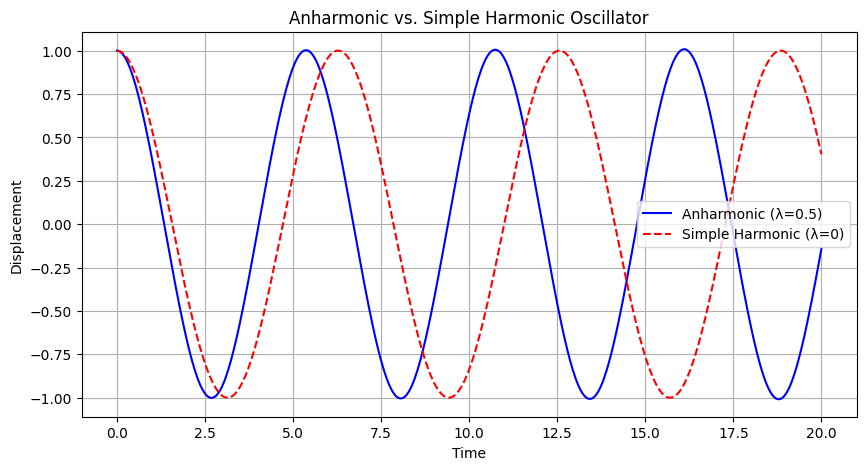

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1. Define the system of ODEs
# State vector y = [position, velocity]
def anharmonic_oscillator(t, y, omega0, lam):
    x, v = y
    dxdt = v
    # Acceleration including the cubic anharmonic term (lambda * x^3)
    dvdt = -omega0**2 * x - lam * x**3
    return [dxdt, dvdt]

# 2. Set Parameters
omega0 = 1.0    # Natural frequency
lam = 0.5       # Anharmonicity constant (stiffness of the non-linearity)
y0 = [1.0, 0.0] # Initial conditions: [initial position, initial velocity]
t_span = (0, 20)
t_eval = np.linspace(t_span[0], t_span[1], 500)

# 3. Solve the ODE
# Use solve_ivp from SciPy for numerical integration
sol = solve_ivp(
    anharmonic_oscillator, 
    t_span, 
    y0, 
    args=(omega0, lam), 
    t_eval=t_eval
)

# 4. Plot results using Matplotlib
plt.figure(figsize=(10, 5))
plt.plot(sol.t, sol.y[0], label=f'Anharmonic (λ={lam})', color='blue')

# Optional: Plot simple harmonic for comparison (set lam=0)
sol_shm = solve_ivp(anharmonic_oscillator, t_span, y0, args=(omega0, 0), t_eval=t_eval)
plt.plot(sol_shm.t, sol_shm.y[0], '--', label='Simple Harmonic (λ=0)', color='red')

plt.title("Anharmonic vs. Simple Harmonic Oscillator")
plt.xlabel("Time")
plt.ylabel("Displacement")
plt.legend()
plt.grid(True)
plt.show()


# Ideas that work....linear, and angular momentum of a field

A perfect crystal lattice is effectively empty, for an electron in the lowest band, 
even though the space is full of atoms  
The absolute value of Energy is equivalent to the fraction of a reduced mass of a proton-electron system, times charge to the fourth power, 
over twice an integer squared times the square of the Plancks constant  
$\longrightarrow$ |E| = $\frac{\mu Q^4}{{2n^2} \hbar^2}$  
There are two special classes of polarizations, those that are purely real(i.e.,$\bar P_z$ = $P_z$ $\forall$ z $\in$ N),  
and those that are purely complex(i.e., $P_z \cap \bar P$ = {0} $\forall$ z $\in$ N)  
The half-form of the Hilbert space is the completion w.r.t. $\vert s \vert^2$ = $\int_\Xi$ ${\widetilde{(s1,s2)}}$  of the space
of polarized for which $\vert s \vert^2$ < $\infty$  
Pairing maps $\longrightarrow$ $\int_\mathbb R$ $\overline {\int_\mathbb {R} \phi (x) e^{- \frac{{ixp}}{\hbar}} dx}$ $\psi$ (p) dp  
Dirac $\delta$ function $\longrightarrow$ $\delta_xi$ = $\xi$(0)  
Faradays Law(The electric field is the negative of the rate of change of the corresponding magnetic field w.r.t time) $\longrightarrow$ $curl \mathbf E$ = - $\frac{\partial \mathbf B}{\partial t}$  
Linear system $\longrightarrow$ Its properties satisfy a finite-dimensional vector space, has a posive-definite quadratic form,
and is independent.  
Configuration vector $\phi$ $\longrightarrow$ $\frac{d}{dt}(\psi, \phi)$ = $\psi, {-I}^*(\phi)$ or $\frac{d\phi}{dt}$ = $\psi$ $\frac{d\psi}{dt}$ = $-I^*(\phi)$,
satisfies the second-order equation $\frac{d^2\phi}{dt}$ = ${-I^*(\phi)}$, where $\phi$ is a scalar
or vector-valued function on 3-space, and ${I^*}$ is a differential operator.  
$\mathbf {\text{Physical law}}$( Seiberg-Witten equations(useful on sympletic 4-manifolds), is an example of a class of $\phi$(a scaling factor). proves one suitable existance and uniqueness theorems of the class of $\phi$s) $\longrightarrow$ When $\phi$ is regarded as a function of x,y,z and t, then it becomes a partial differential equation of the form $\frac{\partial^2 \phi}{dt^2}$ = ${-I^*}(\phi)$.  
Light $\longrightarrow$ Vibrations in the electromagnetic field.  
Energy $\longrightarrow$ An observable corresponding to $\hbar$, times the dynamical operator, and that its an integral
so that we have an **energy conservation law**.  
Heisenberg commutation relation $\longrightarrow$ ${Q_j}{Q_k} - {P_j}{P_k}$ = $i$ $\hbar$ $\delta_j^k$  
Wavefunction of a system $\longrightarrow$ A state vector $\psi$, is a square summable function on $\mathscr M$, and
trajectory $e^{-i Ht}(\psi)$ is a function on $\mathscr M \times \mathbf R$, where $\mathbf R$ is the real line(This is a function of **3n + 1** real variable).  
Expected value of the j-th momentum component $\longrightarrow$ $\frac{\hbar}{i}$ $\int$ $\left(\frac{\partial \psi}{\partial q_j} \overline {\psi} \right)$ $dq_1...dq_{3n}$.  


                                
                                











# Common nomenclecture

Written in polar coordinates $\rho$ and $\theta$ in the unit circle $\rho$<1, we have  
the series u = $ \sum_{\nu=1}^\infty a_\nu \rho^{\nu} \cos$ <a id='plot'></a>  $\nu \theta$  
$\pm$ means $-1^{|r|}$  
$\nabla$ - nabla Differential operator in ordinary 3D space  
$\nabla$h - Gradient of scalar h  
$\nabla$ $\cdot$ $\mathbf A$ - Divergence of a vector  
$\nabla$ $\times$ $\mathbf A$ - Curl of a vector  
$\nabla^2$ - Laplacian operator in ordinary 3D space spacetime $\longrightarrow$ $\frac{\partial^2}{\partial x^2} + \frac{\partial^2}{\partial y^2} + \frac{\partial^2}{\partial z^2}$  
$\Box$ - nabla operator in 3D Minskowski spacetime  
$\Box^2$ - d'Alembertian operator in Minskowski 4D spacetime  
$g_{i,j}, g^{i,j}$ - Covariant, contraviant metric tensor of 3D space, or its components  
$g_{\mu \nu}, g^{\mu \nu}$ - Covariant, contravariant metric tensor of 4D spacetime, or its components  
$\epsilon_0$ - Permittivity of free space  
$\mu_0$ - Permeability of free space  
$\rho, \phi$, z - Cylindrical corodinates in 3D space  
$\sigma$ - Spacetime interval in 4D  
$\phi$ - Electromagnetic scalar potential  
$\omega$ - Angular frequency/speed  
$\overline{V}$ = ($V^\perp)^\perp$ is the closure of V  


**Familiar,recognized and understood equations:**  
If $ \frac{d \alpha} {dt} $ = 0 $\forall$ t, then $\alpha$ is constant  
$(f,\phi,) = \lim_{\alpha \to 0} (f, \phi_n) = 0 $  
$\frac{d \sigma} {d \Omega}$ = $|f(\theta, \phi)|^2$  
$ e^{i \mathbf a \cdot \mathbf X} e^{1 \mathbf b \cdot \mathbf P} \phi_0$ is also a minimum uncertainty state  
$a^\dagger |n \rangle$ = $\sqrt{n + 1} |n +1 \rangle$  
${\hat j_\pm} |j,m \rangle$ = $\hbar$ $\sqrt{j(j + 1) - m(m \pm 1)} |j, m \pm 1 \rangle$ $\longrightarrow$ Angular momentum identity [discrete orientation vector] quantum number(in units of $\frac{\hbar}{2\pi}$)  
A(t) = $e^{+ \frac{iHt}{h}} \mathbf {A}e^{- \frac{iHt}{h}}$  
$\mathbf H$ = $p \hat q - \mathbf L$  
ct' = $ \gamma(ct - \beta x)$  
E = $ ( \mathbf {p^2} c^2 + m^2 c^2)^ \frac{1}{2}$  
$ \mathbf E$ = -$ \frac{\mathbf {\dot A}}{c} - \nabla \varphi$  
$ \forall F \in H L^2(\mathbb C,\mu_\hbar)$, we have  
$ \Vert T_\mathbf a F \Vert^2 L^2(\mathbb C^n,\mu_\hbar)$ = $(\pi \hbar)^{-n}$ $\int \mathbb C_n$ $e^{- \hbar \vert \mathbf a \vert^2}$ $ \mathbf e^{-2 \mathbb R (  \bar {\mathbf a} \cdot \mathbf a ) }$ $ \vert \mathbf F (\mathbf z + \hbar \mathbf a ) \vert^2 $ $ \mathbf e^{- \frac{\vert \mathbf x \vert^2} {\hbar}} $ dx  
                                                          = $(\pi \hbar)^{-n}$ $\int \mathbb C_n$ $e^{- \frac{\vert \mathbf z + \hbar \vert^2}{\hbar}}$ $\vert \mathbf F(\mathbf z + \hbar \mathbf a) \vert^2$ dz  
                                                          = $ \Vert \mathbf F \Vert^2$ $L^2$ $ ( \mathbb C^n,\mu \hbar ) $  
$\prod (e^X)$ = $e^{\pi (X)}$ = $ \sum_{x=0}^\infty \frac{\pi X^m}{m!}$ (Each element is a product of Lie algebra elements. 
                                                                         Its power series is finite dimensional and closed.)                                                                  
The Hilbert-Schmidt norm of a matrix X $\in$ $M_n(\mathbb C)$ $\longrightarrow$ $\Vert X \Vert^2_{HS}$ = $ \sum_{j,k = 1}^{n} |X_{jk}|^2$  
Cauchy-Schwarz inequality - $\Vert {XY} \Vert_{HS} \leq \Vert X \Vert_{HS} \Vert Y \Vert_{HS}$ $\forall$ X,Y $\in$ $M_n(\mathbb C)$  
SO(3) $\longrightarrow \sigma_{\ell}$ = $\pi^{^prime}_{\ell} \circ \phi^{-1}$ = $\pi_\ell$  
$\hat \otimes \longrightarrow$ Hilbert tensor product  
Feynmann path integral $\longrightarrow$ $e^ {- \frac{it \hat {H}}{\hbar}}$ $\psi$ $(X_0)$ = C $\int_{\text{paths with} \\ X(0)=X_0}$ exp$ \left\{ \frac{i}{\hbar}S(x(\cdot),0,t) \right\}$ $\psi$(x(t)) Dx  
Gauge transformation $\longrightarrow$ $U_\gamma Q^{1}_{pre}(f)U^{-1}_{\gamma}$ = $Q^{2}{_{pre}}(f)$, where $U_\gamma$ is the map, and "pre" is for prequantization.  
$\psi_n(r,\phi)$ = $f(r) e^{-in\phi}$, where n is an integer, and f is an arbitrary holomorphic function on $\mathbb C$ with
$\int_0^{\infty}|f(r)|^2$r dr < $\infty$  
Sympletic potential $\longrightarrow$ $\theta$ = $\frac{1}{2}$(p dx - x dp) = $\frac{1}{{2m} \omega}$(p dy - y dp)  
Fourier transform $\longrightarrow$ A constant multiple of a unitary map $\longrightarrow$ $\psi(p)$ = - $\int_\mathbb R$ $\phi$(x)$e^{- \frac{{ixp}}{\hbar}}$ dx dp  
 $C_c^{\infty}(\mathbb {R^n})$ $\longrightarrow$ Space of smooth, compactly supported functions  
                                              
                    
                                                                         
                                              
                                         
                                            
                                                                         
                                                                                         
        


















# Physics of the Universe(Manifolds of pairing maps on an invariant self-adjoint subspace)

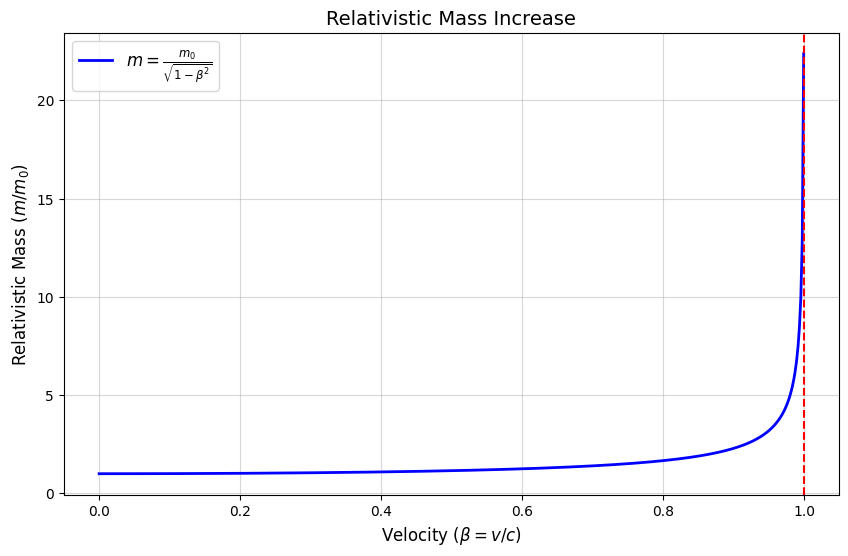

In [3]:
# Limits(an application of a vertical asymptote)

import numpy as np
import matplotlib.pyplot as plt

# Define the range of velocities (beta = v/c) from 0 to just under 1
beta = np.linspace(0, 0.999, 500)

# Relativistic mass formula: m = m0 / sqrt(1 - beta^2)
# We plot the ratio m/m0 (mass increase factor)
mass_ratio = 1 / np.sqrt(1 - beta**2)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(beta, mass_ratio, label=r'$m = \frac{m_0}{\sqrt{1-\beta^2}}$', color='blue', linewidth=2)

# Add labels, title, and grid
plt.title('Relativistic Mass Increase', fontsize=14)
plt.xlabel(r'Velocity ($\beta = v/c$)', fontsize=12)
plt.ylabel('Relativistic Mass ($m / m_0$)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(fontsize=12)

# Highlight asymptote at c
plt.axvline(x=1, color='red', linestyle='--', label='Speed of Light ($v=c$)')

# Show plot
plt.show()


#  A few constants:

$\hbar$*c $\simeq$197.327 MeV $ \cdot$ fm,

Coupling/Fine structure constant $\alpha$ $\rightarrow$ $\frac{e^2}{4 \pi \epsilon_0 \hbar c}$ $\simeq$ $\frac{1}{137.036}$, $m_e$ $c^2$ $\simeq$ 0.511 MeV, $m_p$ $c^2$ $\simeq$ 9.38 MeV.  

Bohr Radius $\longrightarrow$ $r_B$ = $\frac{4 \pi \epsilon_0 \hbar^2}{e^2{m_e}}$ $\approx$ 0.53 $\times$ $10^{-10}$m  

# Useful Formulae:

$\bullet$  1### Relativity: p = mv$\gamma$, E = $\gamma$ m $c^2$, $E^2$ = $p^2$ * $c^2$ + $m^2$ * $c^4$, $\gamma$ = $\frac{1}{\sqrt1 - \beta^2}$,  $\beta$ = $\frac{v}{c}$.  

$\bullet$ 2### de Broglie: $\lambda$ = $\frac{h}{p}$,  Compton: $\lambda_C$ = $\frac{2 \pi h}{mc}(1 - \cos \theta)$,  $\hat{p}$ = $\frac{h}{i}$ $\frac{\partial}{\partial{x}}$,  $\hat{\mathbf p}$ = $\frac{\hbar}{i}$ $\nabla$,  $[\hat{x_i},\hat{p_j}]$ = $i\hbar \delta_{ij}$,  
$[\hat{p_i},f(\hat{\mathbf x})]$ = $\frac{\hbar}{i}$ $\frac{\partial{f}} {\partial{x_i}}$.

$\bullet$ 3### Schr$\ddot{o}$dinger equation: i $\hbar$ $\frac{\partial \psi}{\partial(t)}$ (x,t) =  $(\frac{- i \hbar^2}{2 m}$ $\nabla^2$ + V (x,t)) $\psi (x,t)$,  $\frac{\partial}{\partial(t)}$ $\rho (x,t)$ + $\nabla$ $\cdot$ $\mathbf J$ (x,t)  = 0,  $\rho$ (x,t) = | $\Psi (x,t) |^2$,  $\mathbf J $ (x,t) = $\frac{\hbar} {m}$ Im $[\psi^*$ $\nabla \psi]$. 

$\bullet$ 4### Fourier transforms: $\psi x$ = $\frac{1}{\sqrt2 \pi}$ $\int{dk}$ $\phi$ (k) $e^{ikx}$, $\Phi (k)$ = $\frac{1}{\sqrt2\pi}$ $\int{dx}$ $\Psi$ (x) $e^{-ikx}$, $\int${dx}| $\Psi (x) |^2$ = $\int {dk}$ | $\Phi k |^2$.  
$\frac{1}{2\pi}$ $\int_ {-\infty}^{\infty}$ $e^{ikx}{dx}$ = $\delta(k)$, $\frac{1}{(2\pi)^3}$ $\int$ $e^{ik}$ $\cdot$ ${x}(d)^3{x}$ = $\delta^{(3)}(k)$.  
From the distribution integral $\rightarrow$ $\int_{-\infty}^{\infty} e^{-ax^2 + bx} dx$ = $\sqrt{ \frac{\pi}{a}}$ $e^{\frac{b^2}{4a}}$, when $\Re(\scr{a})$ > 0.  

$\bullet$ 5### expectation value: $\langle\hat{\mathbf Q} \rangle$ $\equiv$ $\langle\psi, \hat{\mathbf Q}\psi \rangle$, $i \hbar \frac{d}{dt} \langle \hat{\mathbf Q \rangle}$ = $\langle[ \hat{\mathbf Q},{\mathbf H}] \rangle$, $\hat{\mathbf Q}$ time idependent. 

$\bullet$ 6### uncertainty: $\vartriangle{A} \equiv || (\hat{A} - \langle \hat{A} \rangle \mathbb{1}) \psi ||$,  
$(\vartriangle{A})^2$ = $\langle \hat{A}^2 \rangle - \langle \hat{A} \rangle^2 \geq$ 0.  
$\vartriangle{A} \vartriangle{B}$ $\geq$ | $\langle \psi$ $\mid$ $\frac{1}{2i}$ $[\hat{A},\hat{B}]$ $\mid$ $\psi$ $\rangle$ | 

$\bullet$ 7### saturation: $(\hat{B} - \langle \hat{B} \rangle \mathbb1) | \psi \rangle$ = i $\lambda (\hat{A} - \langle \hat{A} \mathbb1) | \psi \rangle$, $\lambda \in \Re$.  
$\vartriangle{x} \vartriangle{p} \geq \frac{\hbar}{2}$. For $\psi$ ~ $\exp(- \frac{1}{4} \frac{x^2}{\vartriangle^2})$,  
$\vartriangle{x} = \vartriangle$ and $\vartriangle{p} = \frac{\hbar}{2 \vartriangle}$.  
$\vartriangle{H} \vartriangle{t} \geq \frac{\hbar}{2}$, $\vartriangle{t}$ $\equiv$ $\frac{\vartriangle Q } { |\frac{d Q}{dt} |}$.  

$\bullet$ 8### stationary state: $\psi${x,t} = $\psi (x)e^{- \frac{iEt}{\hbar}}$, $- \frac{\hbar^2}{2m} \nabla^2 \psi(x) + \mathbf V(\mathbf x) \Psi(\mathbf x) = E \psi(\mathbf x)$.   

$\bullet$ 9### variational principle: $E_{gs} \leq \langle \psi, \hat{H} \psi \rangle$, for all normalized $\psi$.   

$\bullet$ 10### Hellmann-Feynmann: $\hat{H}$ $(\lambda)$ $\psi_n$ $(\lambda)$ = $E_n$ $(\lambda)$ $\psi_n$ $(\lambda)$ $\longrightarrow$ $\frac{dE_n (\lambda) } {d \lambda} $ = $\langle \psi_n (\lambda), \frac{d \hat{\mathbf H}{\lambda}} {d \lambda} \Psi_n(\lambda) \rangle$.  

$\bullet$ 11### virial theorem: one dimension: $\langle$ $\frac{\hat{p}^2}{2m} $  $\rangle $ = $\frac{1}{2}$ $\langle \hat{x}$  $\frac{dV}{dx}$ $\rangle$

$\bullet$ 12### central potential: $\langle \frac{\hat{p}^2}{2m} \rangle$ = $\frac{1}{2}$ $\langle{r}$ $\frac{\partial{V}}{\partial{r}} \rangle $.  

$\bullet$ 13### commutator identities:  
[A,BC] = [A,B]C + B[A,C],  
$e^A Be^{-A}$  =$e^{ad_A}B$ = B + [A,B] + $\frac{1}{2!} [A,[A,B]] + \frac{1}{3!} [A,[A,[A,B]]] +...$, this is Hadamards' Lemma using Taylors' expansion, with $ad_A$ as an adjoint action($ad_A(X)$ = [A,X]).  
Note that $e^A$$e^B$ $\neq$ $e^{A + B}$ = $e^C$, with C = A + B + $\frac{1}{2}$[A,B] + $\frac{1}{12}$([A,[A,B]] - $\frac{1}{12}$[B[A,B]]) + ...,  
Its' not evident what the higher terms(...) refer to, althought its's been expanded and expressed in terms of commutators.  
$e^A Be^{-A}$ = B + [A,B], if  [A,[A,B]] = 0,  
$[B,e^A]$ = [$B,A]e^A$, if [ [A,[A,B]] = 0,  
$e^{A + B}$ = $e^A e^B e^{-\frac{1}{2}|A,B|}$ = $e^B e^A e^{\frac{1}{2}[A,B]}$ if [[A,B],A] = [[A,B],B] = 0.  


$\bullet$ 14### matrix exponential: $e^{i M \theta}$ = $\mathbb 1 \cos \theta$ + i M $\sin \theta$,  

$\bullet$ 15### index manipulation: $\mathbf a \cdot \mathbf b$ = $a_i b_i$, $\delta_{ij} B_j$ = $B_i$, $\delta_{ii}$ = 3, ${(\mathbf a \times \mathbf b)}_i$ = $\epsilon_{ijk} \mathbf a_j \mathbf b_k$, $\epsilon$ 123 = 1 .   
$\epsilon_{ijk} \epsilon_{ipq}$ = $\delta_{jp} \delta_{kq}$ - $\delta_{jp} \delta_{kp}$,  
$\epsilon_{ijk} \epsilon_{ijq}$ = 2 $\delta_{kq}$.  

$\bullet$ 16### linear algebra: matrix representation in the basis $(v_{1,...,}v_n)$: $Tv_i$ = $\sum_k $ $T_{kj}$ $v_k$.  

$\bullet$ 17### basis change: $u_k$ = $\sum_j A_{jk}v_j$, T({u}) = $A^{-1} T ({v}) A$.  

$\bullet$ 18### inner product: $\langle{v,v} \rangle$ $\geq$ 0, for all v, $\langle{v,v} \rangle$ = 0 if and only if v = 0, $\langle{u,v} \rangle$ = $\langle{vu} \rangle^*$.  

$\bullet$ 19### Schwarz inequality: |(u,v)| $\leq$ $ ||u ||$ $|| v ||$.  

$\bullet$ 20### Complex vector space: $\langle v,Tv \rangle$ = 0, $\forall$ $\nu$ $\in$ V $\longrightarrow$ T = 0.  

$\bullet$ 21### adjoint: $\langle{u,Tv} \rangle$ = $\langle T^\dagger{u,v} \rangle$ , $(T^\dagger)^\dagger$ = T, $(ST)^\dagger$ = $T^\dagger S^\dagger$.   

$\bullet$ 22### Hermitian operator T: $T^\dagger$ = T, 

$\bullet$ 23### unitary operator U: $U^\dagger U$ = $UU^\dagger$ = $\mathbb1$.  

$\bullet$ 24### orthogonal projector: $P_u$: V $\longrightarrow$ U,  
${P_uP_u}$ = $P_u$,  
$P_u^\dagger$ = $P_u$,  
$ V $ = $ range $ $P_u$ $\oplus$ null $P_u$.  

$\bullet$ 25### bra-kets: $\langle$ u|v $\rangle$ $\equiv$ $\langle$ { u,v} $\rangle$, | Tv $\rangle$ $\equiv$ T|v $\rangle$, $\langle$ Tv | = $\langle v | T^\dagger$, $\langle u | T^\dagger$ v $\rangle$ = $\langle Tu | v \rangle$.  
$| \alpha_1 v_1$ + $\alpha_2 v_2 \rangle$ = $\alpha_1 | v_1 \rangle$ + $\alpha_2 | v_2 \rangle$,   
$\langle \alpha_1 v_1$ + $\alpha_2 v_2 | $ = $\alpha_1^* \langle v_1 | $ + $\alpha_2^* \langle v_2 | $.  
T = | u $\rangle$ $\langle w$ | $\longrightarrow$ $T^\dagger$ = | w $\rangle$ $\langle$ u |,  
**tr**T  = $\langle \mathbf w | \mathbf u \rangle$.      

$\bullet$ 26### orthonormal basis $|i\rangle$: $\langle i|j \rangle$ = $\delta_{ij}$, $\mathbb1$  = $\sum_i|i \rangle \langle i |$.  
$T_{ij}$ = $\langle i|T|j \rangle$ $\longleftrightarrow$ T = $\sum_{i,j} T_{ij}$ |i$\rangle \langle$ j|, $\langle i | T^\dagger | j \rangle^*$, $(T^\dagger)_{ij}$ = $(T_{ji})^*$.  
$[M,M^\dagger]$ = 0 $\longleftrightarrow$ M is unitarily diagonizable.  

$\bullet$ 27### spectral theorem: $T^\dagger$ = T $\longrightarrow$ T = $\sum_k \lambda_k P_k$, $P^\dagger_k$ = $P_k$, $P_k P_l$ = $\delta_{kl} P_l$, $\sum_k P_k$ = $\mathbb 1$.  

$\bullet$ 28### Schr$\ddot{o}$dinger picture: |$\psi,t \rangle$ = $U(t,t_0) | \psi,t_0 \rangle$, $\hat{H}(t)$ = $i \hbar \frac{\partial \mathcal U(t, t_0)}{\partial t} \mathcal U(t_0,t)$,          
U(t,0) = $\exp( \frac{-i \hat{\mathbf H} t} {\hbar} )$, for $\hat{H}$ time independent.  

$\bullet$ 29### Heisenberg picture: $\hat{A}_H(t)$ $\equiv$ $U^\dagger(t,0) \hat{A}_S U(t,0)$, $i \hbar \frac{d \hat{A}_H(t)}{dt}$ = $[\hat{A_\mathbf H}(t)$, $\hat{H}_H(t)]$ + $i \hbar$ $\frac{\partial \hat{A}_H(t)}{dt}$.  

$\bullet$ 30### harmonic oscillator: $\hat{H}$ = $\frac{1}{2m} \hat{p}^2$ + $\frac{1}{2}m \omega^2 \hat{x}^2$ = $ \hbar \omega(\hat{N}$ + $\frac{1}{2})$, $\hat{N}$ = $\hat{a}^\dagger \hat{a}$,  
$\hat{a}$ = $\frac{1}{\sqrt{2}L_0}$ $(\hat{x}$ + $\frac{i \hat{p}}{m \omega})$, $\hat{a}^\dagger$ = $\frac{1}{\sqrt{2}L_0}(\hat{x} - \frac{i \hat{p}}{m \omega})$, $L^2_0$ = $\frac{\hbar}{m \omega}$,  
$\hat{x}$ = $\frac{L_0}{\sqrt{2}}(\hat{a} + \hat{a}^\dagger)$, $\hat{p}$ = $\frac{i}{\sqrt{2}} \frac{\hbar}{L_0}(\hat{a}^\dagger - \hat{a})$,  
$[\hat{a}, \hat{a}^\dagger]$ = 1, $[\hat{N}, \hat{a}]$ = $\hat{-a}$,  
$\hat{a} \varphi_0$ = 0, $\varphi_0(x)$ = $N_0 \exp(- \frac{1}{2} \frac{x^2}{L^2_0})$, $N^2_0$ = $\frac{1}{\sqrt{\pi}L_0}$,  
$\varphi_n$ = $\frac{1}{\sqrt{n!}} (a^\dagger)^n \varphi0 $, $\hat{H} \varphi_n$ = $ \hbar \omega( n + \frac{1}{2}) \varphi_n$, $ \hat{\mathbf N} \varphi_n$ = $n \varphi_n$,  $ \langle \varphi{m}, \varphi{n} \rangle$ = $\delta_{mn}$,  
$\hat{a}^\dagger \varphi_n$ = $\sqrt{n + 1} \varphi_n + 1$, $\hat{a} \varphi_n$ = $\sqrt{n} \varphi_{n - 1}$,  
$\hat{x}_H(t)$ = $\hat{x} \cos \omega{t} + \frac{\hat{p}}{m \omega} \sin{\omega{t}}$,  
$\hat{p}_H(t)$ = $\hat{p} \cos \omega{t} - m \omega \hat{x} \sin \omega{t}$.   

$\bullet$ 31### coherent states: $|\alpha \rangle$ $\equiv$ $e^{\alpha{a}^\dagger - \alpha^*{a}}|0 \rangle$, $\alpha$ = $\frac{\langle \hat{x} \rangle} {\sqrt2{L_0}}$ + $i \frac{\langle \hat{p} \rangle L_0} {\sqrt2 \hbar}$ $\in$ $\mathbb{c}$.  
$\hat{a}| \alpha \rangle$ = $\alpha| \alpha \rangle$, |$\alpha \rangle$ = $e^{-{\frac{1}{2}} | \alpha|^2} e^\alpha a^\dagger |0 \rangle$, $| \alpha, t \rangle$ = $e^{-i \omega t/2}|e^{-i \omega t} \alpha \rangle$.  

$\bullet$ 32### orbital angular momentum: $\hat{L}_x$ = $\hat{y} \hat{p}_z - \hat{z} \hat{p}_y$, $\hat{L}_y$ = $\hat{z} \hat{p}_x - \hat{x} \hat{p}_z$, $\hat{L}_z$ = $\hat{x} \hat{p}_y - \hat{y} \hat{p}_x$,  
$[\hat{L}_x, \hat{L}_y]$ = $i \hbar \hat{L}_z$, $[\hat{L}_y, \hat{L}_z]$ = $i \hbar \hat{L}_x$, $[\hat{L}_z, \hat{L}_x]$ = $i \hbar \hat{L}_y$,  
$\hat{L}^2$ $\equiv$ $\hat{L}_x \hat{L}_x + \hat{L}_y \hat{L}_y + \hat{L}_z \hat{L}_z$, $[\hat{L}^2$, $\hat{L}_i]$ = 0.  
$\nabla^2$ = $\frac{\mathbf 1} {r}$ $\frac{\partial^2}{\partial \mathbf r^2}$ $\mathbf r$ - $\frac{\mathbf 1} {\mathbf r^2}$ $\frac{\hat L^2} {\hbar^2}$,  
$\hat{L}^2$ = $- \hbar^2$ $(\frac{\partial^2}{\partial \theta^2}$ + $\cot$ $\theta$ $\frac{\partial}{\partial \theta}$ + $\frac{1}{\sin^2 \theta}$ $\frac{\partial^2}{\partial \phi^2})$,  
$\hat{L}_z$ = $\frac{\hbar}{\mathbb i}$ $\frac{\partial}{\partial \theta}$, $\hat{L}_\pm$ = $\hbar e^{\pm i \phi}$ $(\pm\frac{\partial}{\partial \theta}$ + i $\cot \theta$ $\frac{\partial}{\partial \theta})$.  
$Y_{\ell m}$ $(\theta, \phi)$ = $\langle \theta \phi$ |  ${\ell m}$ $\rangle$ = $Y_{\ell m}$ $(\Omega)$ $\equiv$ $\mathcal N_{\ell m}$ $P^m_\ell$ $(\cos$ $\theta)$ $e^{i m \theta}$.  
$L_z Y_{\ell m}$ = $\hbar$ $\mathbf m$ $\mathbf Y_{\ell m}$, $\mathbf L^\angle$ $Y_{\ell m}$ = $\hbar^\angle$ $\ell$ ( $\ell + 1 )$ $Y_{\ell m}$,  
$\int d \Omega \mathbf Y^*_{\ell' m'} (\Omega)$ = $\delta_{\ell' \ell} \delta_{m' m}$, $\sum_{\ell = 0}^\infty \sum_{m = - \ell}^\ell Y^*_{\ell m} (\Omega)$ = $\delta$ $(\cos\theta - \cos\theta')$ $\delta$ $(\phi - \phi')$.  
$Y_{0,0}(\theta, \phi)$ = $\frac{1} {\sqrt{4 \pi}}$, $Y_1$, $\pm 1 (\theta, \phi)$ = $\mp {\sqrt \frac{3}{8 \pi}}$ $\sin \theta$ $e^{\pm i \phi}$, $Y_{1,0}$ $(\theta, \phi)$ = ${\sqrt \frac{3}{4 \pi}}$ $\cos$ $\theta$.  

$\bullet$ 33### central potentials: $\psi(r, \theta, \phi)$ = $\frac{u(r)}{r}$ $Y_{\ell m}(\theta, \phi)$,  
$ (- {\frac{\hbar^2}{2m}}$ $ \frac{d^2}{dr^2}$ + V(r) + $\frac{\hbar^2 \ell (\ell + 1)} {2mr^2}) u(r) $ = Eu(r), u(r) $\approx$ $r^{\ell + 1}$, as r $\longrightarrow$ 0.  

$\bullet$ 34### spin one-half: $\hat{H}$ = $- \mu \cdot B$, $\hat{\mu}$ = $ g \frac{e \hbar}{2mc}$ $\frac{1}{\hbar} \hat{S}$, $\mu_B$ = $\frac{e \hbar}{2m_eC}$, $ \hat{\mu_e}$ = -2 $ \mu_B$ $\frac{\hat{\mathbf S}}{\hbar}$.                          
$| 1 \rangle$ $\equiv$ $| Z; + \rangle$ = $| + \rangle$ = $\begin{pmatrix}1\cr0\cr\end{pmatrix}$, $|2 \rangle$ $\equiv$ $|Z; - \rangle$ = $| - \rangle$ = $\begin{pmatrix}0\cr1\cr\end{pmatrix}$,  
$\hat{S}_i$ = $\frac{\hbar}{2} \sigma_i$, $\sigma_x$ = $\begin{pmatrix}0 & 1\cr 1 & 0\cr\end{pmatrix}$, $\sigma_y$ = $\begin{pmatrix}0 & -i\cr i & 0\cr\end{pmatrix}$, $\sigma_z$ = $\begin{pmatrix}1 & 0\cr 0 & -1\cr\end{pmatrix}$.  
$[\sigma_i, \sigma_j]$ = $2i \epsilon_{ijk} \sigma_k$, $[\hat{S_i}, \hat{S_j}]$ = $i \hbar \epsilon_{ijk} \hat{S_k}$,  
$\sigma_i \sigma_j$ = $\delta_{ij} \mathbb1 + i \epsilon_{ijk} \sigma_k$, $(\sigma \cdot \mathbf a) (\sigma \cdot \mathbf b)$ = $\mathbf a \cdot \mathbf b \mathbb 1 + i \sigma \cdot (\mathbf a \times \mathbf b)$,  
$e^{i \mathbf a \cdot \sigma}$ = $\mathbb1 \cos \mathbf a + i {\mathbf \sigma}  \cdot  \hat{\mathbf a} \sin a$, $ \mathbf a$ = $\hat{\mathbf a} a$, a = $|\mathbf a|$.  
$\hat{S_n}$ $\equiv$ $\mathbf n \cdot \hat{S}$ = $\frac{\hbar}{2} \mathbf n \cdot \sigma$, $\hat{S_n} | \mathbf n; \pm \rangle$ =  $\pm \frac{\hbar}{2} | \mathbf n; \pm \rangle$, $| \mathbf n \rangle$ $\equiv$ | $\mathbf n ; + \rangle$, $\langle \mathbf n |  \hat{\mathbf S} | \mathbf n \rangle$ = $\frac{\hbar}{2} \mathbf n$,  
$ | \mathbf n; _ \rangle$ = $\cos \frac{\theta}{2} | + \rangle + \sin \frac{\theta}{2} \mathbf{e}^{\mathbf{i} \theta} | - \rangle$,  
$ | \mathbf n; - \rangle$ = $ - \sin \frac{\theta}{2} \mathbf{e}^- {\mathbf{i} \theta} | + \rangle$ + $\cos \frac{\theta}{2} | - \rangle$,  
$ \hat{R_n} (\alpha)$ $\equiv$ $ \exp(- \frac{i}{\hbar} \alpha \hat{S_n})$, $ \hat{R_n} (\alpha) | \mathbf n' \rangle$ = $ | n" \rangle$, with $ \mathbf n"$ = $ \mathcal{R_\mathbf n} (\alpha) \mathbf n'$,  
$ \hat{R_n}(\alpha) \hat{\mathbf S} \hat{R_n}(\alpha)$ = $ \mathcal{R_n}(\alpha) \hat{\mathbf S}$.  

$\bullet$ 35### spin precession: $ \hat{H}$ = $ {\mathbf \omega_L} \cdot \hat{S}$, $ {\mathbf \omega_L}$ = $ - \gamma{\mathbf B}$, $ \hat{\mathbf \mu}$ = $ \gamma \hat{\mathbf S}$.   

$\bullet$ 36### general angular momentum: $ [ \hat{J_i}, \hat{J_j}]$ = $ i \hbar \epsilon_{ijk} \hat{\mathbf J_k}$ $\longleftrightarrow$ $\hat{\mathbf J} \times \hat{\mathbf J}$ = $ i \hbar \hat{\mathbf J}$, $ [\hat{\mathbf J^2}, \hat{\mathbf J_i}] $ = 0.  
$ \hat{\mathbf J_ \pm}$ = $ \hat{\mathbf J_x} \pm i \hat{\mathbf J_y}$, $ \hat{(J_ \pm)^\dagger}$ = $\hat{\mathbf J_\mp}$, $\hat{\mathbf J_x}$ = $\frac{1}{2} (\hat{\mathbf J_+} + \hat{\mathbf J_-})$, $\hat{\mathbf J_y}$ = $\frac{1}{2i}(\hat{\mathbf J_+} - \hat{\mathbf J_-})$,  
$ [\hat{\mathbf J_z}, \hat{\mathbf J_ \pm}]$ = $ \pm \hbar \hat{\mathbf J_ \pm}$, $[\hat{\mathbf J_+}, \hat{\mathbf J_-}]$ = $2 \hbar \hat{\mathbf J_z}$, $[ \hat{\mathbf J^2}, \hat{\mathbf J_\pm}]$ = 0,  
$\hat{\mathbf J^2}$ = $\hat{\mathbf J_+} \hat{\mathbf J_-}$ + $\hat{\mathbf J^2_z}$ - $\hbar$ $\hat{\mathbf J_z}$ = $\hat{\mathbf J_-} \hat{\mathbf J_+}$ + $\hat{\mathbf J^2_z}$ + $\hbar$ $\hat{\mathbf J_z}$.  
$\hat{\mathbf J^2} |{\mathbf {jm}} \rangle$ = $\hbar^2 \mathbf j(\mathbf j + 1) | \mathbf {jm} \rangle$ = $ \hbar \mathbf m | \mathbf {jm} \rangle$,  
$ \mathbf m$ = $ - \mathbf j,...,\mathbf j$                             
$ \hat{\mathbf j_\pm} | {\mathbf jm} \rangle$ = $\hbar$ $\sqrt{{{\mathbf j} {(\mathbf j + 1)}} - {\mathbf m}{(\mathbf m \pm 1)}}$ $ | \mathbf j, \mathbf m \pm 1 \rangle$.  
$\hat{R^\dagger_n}(\alpha) \hat{\mathbf J} \hat{R_n}(\alpha)$ = $\mathcal R_n (\alpha) \hat{\mathbf J}$, $\hat{\mathbf R_n}(\alpha)$ = $e^{ - i \frac{\alpha}{\hbar} {\mathbf n} \cdot {\mathbf J}}$.  

$\bullet$ 37### addition of angular momentum: $\hat{\mathbf J}$ = $\hat{\mathbf J_1} + \hat{\mathbf J_2}$.  

$\bullet$ 38### uncoupled basis: $ | j_1 j_2; \mathbf m_1 \mathbf m_2 \rangle $ $ CSCO : (\hat{\mathbf J^2_1}, \hat{\mathbf J^2_2}, \hat J_{1z}, \hat{j_{2z}})$,   

$\bullet$ 39### coupled basis:$ | {j_1} {j_2 ;} \mathbf{jm} \rangle$ CSCO : $ (\hat{\mathbf J^2_1}, \hat{J^2_2}, \hat{\mathbf j^2}, \hat{j_z})$.  
$ j_1 \otimes j_2 $ = $ (j_1 + j_2) \oplus  (j_1 + j_2 - 1)\oplus...\oplus |j_1 - j_2)$.  
$ | \mathbf j_1 \mathbf j_2; \mathbf{jm} \rangle$ = $ \sum_{\mathbf m_1 + \mathbf m_2 = \mathbf m}$ $ | {\mathbf j_1}{\mathbf j_2}; {\mathbf m_1}{\mathbf m_2} \rangle$ $\underbrace{\langle{\mathbf j_1 \mathbf j_2}; {\mathbf m_1 \mathbf m_2} | {\mathbf j_1 \mathbf j_2}; \mathbf{jm} \rangle}_{\text{Clebsh-Gordan coefficient}}$.  
$ \hat{\mathbf J_1} \cdot \hat{\mathbf J_2}$ = $\frac{1}{2}$ $( \hat{\mathit J_{1 +}} \hat{\mathit J_{2 -}} + \hat{\mathit J_{1 -}} \hat{\mathit J_{2 +}})$ + $ \hat{\mathit J_{1z}}$ $\hat{\mathit J_{2z}}$ = $ \frac{1}{2}$ $(\hat{\mathbf J^2} - \hat{\mathbf J^2_1} - \hat{\mathbf J^2_2})$.  

$\bullet$ 40### Hydrogen atom: $ \hat{H}$ = $ \frac{\hat{\mathbf p^2}} {2 {\mathbf m}}$ - $ \frac{\mathit Z e^2}{r}$, $ \mathit Z$ = 1 for hydrogen.  
$ \mathit E_n$ = $ - \frac{\mathit {Z^2 e^2}}{2a_0} \frac{1}{\mathbf n^2}$, $a_0$ = $ \frac{\hbar^2}{me^2}$ $ \simeq$ 52.9 pm, $ \frac{e^2}{2a_0}$ = $ \frac{1}{2} \mathbf {mc^2} \alpha^2$ $ \equiv$ Ry $ \simeq$ 13.6 eV.  
$ \psi_{n \ell m} (\mathbf X)$ = $ \mathcal N ( \frac{r}{a_0})^\ell$ $ ( polynomial \in {\frac{r}{a_0}} of degree [{\mathbf {n} - (\ell + 1)}])$ $ e^{- \frac{\mathit Zr} {\mathbf {n a_0}}}$ $\mathbf Y_{\ell m}$ $(\theta, \phi)$,  
$ \psi_{100} ( \mathbf r, \theta, \phi)$ = $ {\sqrt{\frac{\mathit Z^3}{\pi a^3_0}} e^-{\mathit Z/a_0}}$.  
$ \mathit Z$ = 1: $ \langle r \rangle$ = $ \frac{1}{2} a_0(3n^2 - \ell(\ell + 1))$, $ \langle \frac{1}{r} \rangle$ = $ \frac{1}{a_0n^2}$,  
$ \langle \frac{1}{r^2} \rangle$ = $ \frac{1}{a^2_0 n^3 (\ell + \frac{1}{2})}$, $ \langle \frac{1}{r^3} \rangle$ = $ \frac{1}{\mathbf {a^3 n^3} \ell (\ell + \frac{1}{2}) (\ell + 1)}$.  

$\bullet$ 41### Fine structure corrections of the Hydrogen atom: $ \mathit E_{n \ell {\mathbf j m_j}}$ = $ - \frac{e^2}{2 \mathbf a_0}$ $ \frac{1}{\mathbf n^2}$ $ (1 + \frac{\alpha^2}{\mathbf n^2} [\frac{\mathbf n}{\mathbf j + \frac{1}{2}} - \frac{3}{4}])$.   

$\bullet$ 42### Density matrix: $ \mathit E$ = $ [ (\mathbf p_1, | \psi_1 \rangle), ..., ( \mathit p_n, | \psi_n \rangle)]$, $ \mathit p_1,...,\mathit p_n$ > 0, $ p_1 +...+ p_n$ = 1,  
$\rho_\mathit E$ $\equiv$ $\sum_{a = 1}^n$ $\mathit p_a | \psi_a \rangle \langle \psi_a |$, $ \langle \hat{\mathit Q \rangle_\mathit E}$ = tr $ (\mathit Q_{\rho_{\mathit E}})$.  
General $\rho$ is positive semidefinite, and tr $\rho$ = 1. Pure state $\longleftrightarrow$ **tr** $\rho^2$ = 1.  
spin one-half density matrix: $\rho$ = $ \frac{1}{2} ( \mathbb 1 + \mathbf a \cdot \sigma)$, | $\mathbf a |$ $\leq$ 1.  

$\bullet$ 43### time evolution: $ i \hbar \frac{\partial \rho}{\partial t}$ = $ [ \hat{H}, \rho]$.  

$\bullet$ 44### Schmidt decomposition: | $ \psi AB \rangle$ = $ \sum_{k = 1}^r$ $ \sqrt {\mathit p_k}$ | $\mathbf k_A \rangle$ $\otimes$ | $ \mathit k_B \rangle$, r $ \leq$ $\mathbf d_A$ $\leq$ $\mathbf d_B$,  
$ \rho_A$ = $ \sum_{k =1}^r$ $ \mathit p_k | \mathit k_A \rangle \langle \mathit k_A |$,  
$ \rho_B$ = $ \sum_{k =1}^r$ $ \mathit p_k | \mathit k_B  \rangle \langle \mathbf k_B |$, $\langle k_A | k'_A \rangle$ = $ \delta_{k,k'}$, $ \langle k_B | k'_B \rangle$ = $ \delta_{k,k'}$,  

$\bullet$ 45### Lindblad equation: $ \frac{\partial \rho} {\partial t}$ = $ \frac{1} {i \hbar}$ $[ \mathbf H, \rho ]$ + $ \sum_k$ $( \mathbf L_k \rho \mathbf L^\dagger_k$ - $\frac{1} {2}$ $[ \mathbf L^\dagger_k \mathbf L_k, \rho])$.                              

$\bullet$ 46### electromagnetic couplings: $ \hat{H}$ = $ \frac{1}{2m}(\hat{\mathbf p}) - \frac{q}{c}$ $\mathbf A$ $(\hat{x}, t)^2$ + q $\phi(\hat{\mathbf x, t})$ (no spin).   

$\bullet$ 47### gauge tranformations: $\mathbf A'$ = $ \mathbf A + \nabla \wedge$, $ \phi'$ = $ \phi$ - $\frac{1}{c}$ $ \frac{\partial \wedge}{\partial {\mathbf t}}$, $ \Psi'$ = $ \exp(i \frac{q \wedge}{\hbar c})$ $\Psi$.  

$\bullet$ 48### Pauli Hamiltonian (electron): $ \hat{\mathbf H}_{Pauli}$ = $ \frac{1}{2m_e} (\hat{\mathbf p} + \frac{e}{c} \mathbf A)^2$ + $\frac{e \hbar}{2m_e c}$ $\sigma$ $\cdot$ $\mathbf B$ - e $\phi$ $(\hat x,t)$.  

$\bullet$ 49### time-independent purtabation theory:  nondegenerate:$ |n \rangle_\lambda$ = $ | n^{(0)} \rangle - \lambda$ $ \sum_{k \neq n} \frac{\delta \mathbf H_{kn}} {\mathbf E^{(0)}_k - \mathbf E^{(0)}_n}$ $ |k^{(0)} \rangle$ + $ \mathcal O (\lambda^2)$,  
$ E_n (\lambda)$ = $ E^{(0)}_n$ + $ \lambda \delta \mathbf H_{nm}$ - $\lambda^2$ $\sum_{k \neq n} \frac{ | \delta \mathbf H_{kn} |^2} {\mathbf E^{(0)}_k - \mathbf E^{(0)}_n}$ + $\mathcal O (\lambda^3)$.   

$\bullet$ 50### degeneracy lifted at $\mathcal O (\lambda)$: good basis:  
$ \delta \mathbf H_{\mathcal {ij}}$ $\equiv$ $ \langle \Psi^{(0)}_\mathcal I | \delta \mathbf H | \Psi^{(0)}_\mathcal J \rangle$ = $ \mathbf E^{(1)}_\mathcal {nJ}$ $ \delta_\mathcal {IJ}$,  
$ | \Psi_\mathcal I \rangle_\lambda$ = $ | \Psi^{(0)}_{\mathcal I} \rangle - \lambda \sum_p \frac{\delta \mathbf H_{p \mathcal I}} {\mathbf E^{(0)}_p - \mathbf E^{(0)}_n} | \mathbf p^{(0)} \rangle + \sum_{K \neq \mathcal I} \frac{ | \Psi^{(0)}_K \rangle} {\mathbf E^{(1)}_{n \mathcal I} - \mathbf E^{(0)}_{n \mathcal K}} \sum_p \frac{ \delta \mathbf H_\mathcal K p \delta \mathbf H_pl} {\mathbf E^(0)_p - \mathbf E^(0)_n}$ + $\mathcal O \lambda^2$,  
$ \mathbf E_{n \mathcal I} (\lambda)$ = $\mathbf E^{(0)}_n + \lambda \delta \mathbf H_{\mathcal II} -\lambda^2 \sum_p \frac{ | \delta \mathbf H_p \mathcal I |^2}{\mathbf E^{(0)}_p - \mathbf E^{(0)}_n}$ + $\mathcal O (\lambda^3)$.  

$\bullet$ 51### WKB quantization with a, b turning points or hard walls:  
$\int_a^b k(x') dx'$ = $ (\mathbf n + \beta) \pi$, $\mathbf n$ = $0,1,2,...,$ $\beta$ = $1 - \frac{1}{4}$ (Number of turning points).  

$\bullet$ 52### time-dependent perturbations: $\hat{\mathbf H} (t)$ = $\hat{\mathbf H^{(0)}} + \delta \mathbf H (t)$, $ | \Psi (t) \rangle$ $\equiv$ $e^{i \hat{\mathbf H}^{(0)} {t/ \hbar}} | \Psi (t) \rangle$,  
$ i \hbar \frac{ \mathbf d}{\mathbf dt} | {\tilde \Psi} (t) \rangle$ = $ {\tilde \delta} \mathbf H (t) | \Psi (t) \rangle$, $ \delta \mathbf H (t)$ $\equiv$ $e^{i \hat{\mathbf H}^{(0)}{t/ \hbar}} \delta \mathbf H (t) e^{- i \hat{\mathbf H^{(0)}} {t / \hbar}}$,    
$ | \tilde \Psi (t) \rangle$ = $ | \Psi(0) \rangle + \int_0^t \frac{ \delta \mathbf H(t')} {i \hbar} | \Psi(0) \rangle \mathbf dt' + \mathcal O( \delta \mathbf H^2)$.  

$\bullet$ 53### Fermis' golden rule: $\hat{\mathbf H}$ = $ \hat{\mathbf H^{(0)}}$ + V, $\hat{\mathbf H}$ = $\hat{\mathbf H^{(0)}} + 2 \mathbf H' \cos \omega t$,  
w = $ \frac{2 \pi}{\hbar} | \mathbf V_f |^2 \rho(\mathbf E_f)$, w = $ \frac{2 \pi}{\hbar} | \mathbf H'_f |2 \rho(\mathbf E_f)$,                                          

$\bullet$ 54### adiabatic approximation: $ | \Psi(t) \rangle$ $\simeq$ $e^{i \theta_k(t)} e^{i \gamma_k(t)} | \Psi_k(t) \rangle$, $ \hat{\mathbf H} (t) | \Psi_k(t) \rangle$ = $ \mathbf E_k(t) | \Psi_k(t) \rangle$,  
$ \theta_k(t)$ = $ -\frac{1}{\hbar} \int_0^t \mathbf E_k(\mathbf t') {\mathbf dt'}$,  $ \gamma_k(t)$ = $ \int_0^t \nu_k(t') {\mathbf dt'}$, $ \nu_k(t)$ = $ i \langle  \Psi_k(\mathbf t) | {\dot \Psi_k}(t) \rangle$.  

$\bullet$ 55### Berrys' phase: $ \gamma_n(\Gamma_{if})$ = $ \int_{\Gamma if} \mathbf A_n(\mathbf R) \cdot  d{\mathbf R}$, $ \mathbf A_n(\mathbf R)$ $\equiv$ $ i \langle \Psi_n(\mathbf R) | \nabla_{\mathbf R} | \Psi_n(\mathbf R) \rangle$.  

$\bullet$ 56### scattering on the half line: $ \Psi(\mathbf x)$ = $ e^{1 \delta} \sin(\mathbf {kx} + \delta)$, $ \Psi_s(\mathbf x)$ = $ e^{i \delta} \sin \delta e^{ikx}$, $\mathbf x$ > $ \mathbf R$.   

$\bullet$ 57### time delay: $\vartriangle t$ = $ 2\hbar \delta'( \mathbf E_0)$.  

$\bullet$ 58### Levinsons' theorem: $ \mathit N_b$ = $\frac{1}{\pi} ((\delta)(0) - \delta(\infty))$.  

$\bullet$ 59### resonance, Breit-Wigner: $ | \Psi_s |^2$ $\simeq$ $\frac{ \frac{1}{4} \Gamma^2} {(\mathbf E - \mathbf E_\alpha)^2 + \frac{1}{4} \Gamma^2}$.  

Energy dependance of the squared scattering amplitude $ |\Psi_s|^2$ near resonance.

$\bullet$ 60### scattering in 3D: $ \Psi(\mathbf r)$ = $ \varphi(\mathbf r) + \Psi_s(\mathbf r)$ $\simeq$ $e^{ikz} + f_k(\theta, \phi)$ $ \frac{e^{ikr}}{\mathbf r}$, $\mathbf r$ $\gg$ a.  
$ \frac{d \sigma}{d \Omega}$ = $ |f_k(\theta, \phi) |^2$, $ \sigma$ = $\int |f_k(\theta, \phi)|^2 d \Omega$.  

$\bullet$ 61### Rayleigh: $e^{ikz}$ = ${\sqrt 4 \pi} \sum_{\ell = 0}^\infty {\sqrt{2 \ell + 1}}$ $i^\ell \mathbf Y_{\ell 0}(\theta) j_\ell(kr)$.  

$\bullet$ 62### phase shifts: $f_k(\theta)$ = $ \frac{\sqrt(4 \pi)} {\mathbf k} \sum_{l = 0}^\infty \sqrt{2l + 1} \mathbf Y_{l 0}( \theta) e^{i \delta_l}$,  
$ \sigma$ = $ \frac{4 \pi}{\mathbf k^2} \sum_{l = 0}^\infty(2 l + 1) \sin^2 \delta_{l}$.  
$ \Psi \mathbf r$ | l = $ \mathbf A_{l} \mathbf j_{l} \mathbf(kr)$ + $\mathbf B_{l} \mathbf n_{l} \mathbf{kr}$ $\mathbf Y_{l 0} (\theta)$,  
$ \mathbf r$ > $\mathbf a$,  
$ \tan \delta_{l}$ $\equiv$  - $\frac{\mathbf B_(l)}{\mathbf A_(l)}$.  
    
    

# Sample practice and other useful equations:

$\bullet$  d Alemberts Principle $\longrightarrow$  $\sum_i \langle \mathbf {F}_i(\mathbf c(t),t) - \mathbf {m}_i {c_i(t)}, \mathbf {v}_{i} \rangle$ = 0 $\forall$ tangent vectors $\mathbf v$ at $\mathbf {M}_{\mathbf c(t)}$

$\bullet$  $n^{th}$ Taylor Polynomial about x = $x_0$ for f , $p_n(x)$ = $ f(x_0) + f'(x_0)(x - x_0) + \frac{f''(x_0)}{2!}(x - x_0)^2 +...\frac{f^{(n)}{(x_0)}}{n!}(x - x_0)^n $,  
$\sum_{k=0}^\infty$ $\frac{ ({-i} * {\theta / 2} * {X} )^k} {k!}$ 



$\bullet$ Airy equation $\longrightarrow$ $ \frac{d^2 \psi} {dU^2}$ - $u \psi (u)$ = 0 

$\bullet$ Jacobi identity $\longrightarrow$ [X,[Y,Z]] + [Y,[X,Z]] + [Z, [X,Y]] = 0

$\bullet$ Stokes theorem(Line Integrals) $\longrightarrow$ $\iint_s curl \mathbf F \cdot d \mathbf S$ = $\int_c \mathbf F \cdot d \mathbf r$, where C is a closed curve, and $\mathbf F$ is a vector field defined on C.  




$\bullet$ A sympletic manifold (N, $\omega$) is quantzable (for a particular value of $\hbar$) if
$\frac{1}{{2 \pi \hbar}}$ $\int_s \omega \in \mathbb Z$ for every closed surface S in N   


$\bullet$ Probability density function(Gaussian distribution) $\longrightarrow$ f(x) = $\frac{1}{\sigma \sqrt{2 \pi}}$ $e^{- \frac{(x - \mu)^2}{2 \sigma^2}}$  

                                                                                 

$\bullet$ Bells Inequality $\longrightarrow$ 4($\epsilon + \delta$) = $\sqrt{2}$ - 1 

$\bullet$ Poisson bracket of f and g or Moyal bracket $\longrightarrow$ [f,g] = $\frac{\partial f}{\partial q_1}$ $\frac{\partial g}{\partial p_1}$ +...+ $\frac{\partial f}{\partial q_n}$ $\frac{\partial g}{\partial p_n}$ - $\frac{\partial f}{\partial p_1}$ $\frac{\partial g}{\partial q_1}$ - ... - $\frac{\partial f}{\partial p_n}$ $\frac{\partial g}{\partial q_n}$  


$\bullet$ Laguerre Polynomials $\longrightarrow$ $f_{n,l}(r) := L_{n - l - 1}^{2l +  1}$$ \left( \frac{2r}{nr_B} \right)$, where $r_B$ is the Borh radius.  



$\bullet$ Rydberg formula $\longrightarrow$ $\frac{1}{\lambda}$ = $R_H \left({\frac{1}{n^2} - \frac{1}{m^2}} \right)$,  
where $R_H$ is the Rydberg constant.  



$\bullet$ Rayleigh formula $\longrightarrow$ $\frac{8\pi\nu^2{kT}\vartriangle\nu}{c^3}$ $\hbar$ $e^{-\left(\frac{\hbar}{k}\right) \left(\frac{\nu}{T} \right)}$, 
Wiens formula $\longrightarrow$ $\frac{A \nu^3 e^{-b \nu}}{T \vartriangle \nu}$, where A and b are constants(does not fit experimental facts for small $\frac{ \nu}{T}$,  
although it avoids the paradox of infinite total energy.


$\bullet$ Radon-Nikodym Theorem(derivative of $\nu$ w.r.t $\mu$) $\longrightarrow$ $\nu (E)$ = $\int_E \rho(s) d\mu(s)$  
There exists a measurabe function $\rho$ which is the density of $\nu$ w.r.t $\mu$ 

$\bullet$ Schr$\ddot{o}$dinger operator $\longrightarrow$ $\lim_{X \to \infty} \frac{\beta([0,X])}{\beta_q([0,X])}$ = $(2 \pi \hbar)^N$, where 
$\beta([0,X])$ is a continous measure space of the set of classic Hamiltonian, $\beta_q([0,X])$ is the dicrete
measure of the number of eigenvalues < X, and N is the number of dimensions in configuration space.  


$\bullet$ Schurs Theorem $\longrightarrow$ $U^*{\mathbf A}U$ = T = $[T_{ij}] \in M_n(\mathbb C)$, $T_{ij}$ = 0(i > j).  


$\bullet$ Angular momentum in the tensor product space $\longrightarrow$ $\hat j_i$ = ${\hat j_i^{(1)}} \otimes \mathbb 1 + \mathbb 1 \otimes  {\hat j_i^{(2)}}$ satisfy [$\hat j_i, \hat j_j$] = ${i \hbar \epsilon_{ijk} {\hat j_k}}$ acting on $V_1 \otimes V_2$  


$\bullet$ Maxwells equations $\longrightarrow$  
$\nabla \cdot \mathbf E$ = $ \frac{\rho}{\epsilon_0}$  
$\nabla \cdot \mathbf B$ = 0  
$\nabla \times \mathbf E$ = $ - \frac{\partial B}{\partial t}$  
$\nabla \times \mathbf B$ = $\mu_0$  $\left( \mathbf {J} + \epsilon_0 \frac{\partial \mathbf E}{\partial t} \right)$  
            

$\bullet$ Abelian/Commutatitive $\longrightarrow$ $\forall$ a,b $\in$ G, a $\cdot$ b = b $\cdot$ a  


$\bullet$ Matrix representation of 2-D Hilbert space $\longrightarrow$ $H^2$ = $\frac{1}{2}$ $\begin{pmatrix}1 & 1 \cr 1 & -1 \end{pmatrix}$ $\begin{pmatrix}1 & 1 \cr 1 & -1 \end{pmatrix}$ = $\begin{pmatrix}1 & 0 \cr 0 & 1 \end{pmatrix}$ = I,  
where H is for the Hadamard gate, and I is the identity.

$\bullet$ Liebniz Rule $\longrightarrow$ $\frac{d}{dt} \int_{- \infty}^\infty |\psi{x,t}|^2$ dx = $\int_{- \infty}^\infty \frac{\partial}{\partial t} |\psi{x,t}|^2$ dx = 0  



$\bullet$ Wave function for a particle in a box:$\longrightarrow$ $\Psi$(x,t) = $\sum_{n=1}^\infty$ $C_n$ $\sqrt{\frac{2}{a}}$ $\sin(\frac{n \pi}{a}x)$ $e^{- i\left( \frac{n^2 \pi^2 \hbar}{2m {a}^2} \right)t}$  


$\bullet$ Ground state for a particle in a box $\longrightarrow$ $\Psi_n$(x) = ${\sqrt \frac{2}{a}}$ $\sin \left( \frac{n \pi}{a}x \right)$  


$\bullet$ Ground state wave function $\longrightarrow$ $\Psi_0$ = $\left( \frac{m \omega}{\pi \hbar} \right)^\frac{1}{4}$ $e^{- \frac{m \omega}{2 \hbar}x^2}$;
The exponent $\frac{1}{4}$ is derived from squaring and substituting the result of 1-Dimensional normalized Gaussian integral.  



$\bullet$ Gaussian integral $\longrightarrow$ If $z^2$ = ${a}x^2$, and dz = $\sqrt{a}$dx, then $\int_{- \infty}^\infty$ $e^{- a x^2}$ dx = $\sqrt{ \frac{\pi}{a}}$[Highly simplified]  


$\bullet$ Hookes Law $\longrightarrow$ F = - $\frac{dV}{dx}$ = - $\frac{d}{dx}$ $\left( \frac{1}{2} k {x^2} \right)$ = -k x = m a = m $\frac{d^2(x)}{dt^2}$    


$\bullet$ Energy spectrum of the Transmon qubit $\longrightarrow$ $\omega_j$ = $\left( \omega - \frac{\delta}{2} \right) j$ + $\frac{\delta}{2} j^2$  


$\bullet$ Pure density operator, and state $\longrightarrow$ $tr \rho^2$ = $tr \rho$ = $\mathbb 1$ ; $\frac{1}{N}$ < tr $\rho$ < $\mathbb 1$ $\rightarrow$ positive-definiteness, where $\lambda_j$ $\geq$ 0 ($\lambda_j$ are the eigenvalues and 'N' is the Hilbert space dimension ).   


$\bullet$ Traceless Pauli matrices $\longrightarrow$ $\rho$ = $\frac{1}{2}$ $\left[ \begin{pmatrix}1 & 0 \cr 0 & 1 \end{pmatrix} + x \begin{pmatrix}0 & 1 \cr 1 & 0 \end{pmatrix} + y \begin{pmatrix}0 & -i \cr i & 0 \end{pmatrix} + z \begin{pmatrix}1 & 0 \cr 0 & -1 \end{pmatrix} \right]$  = $\frac{1}{2}$ ( **I** + $\vec{r} \cdot \vec{\sigma})$, where $\vec{r} \in \mathbb R^3$, and $\vec{\sigma}$ = (x,y,z). 

# Test your comprehension:

# Section A

##

Q1. Time-dependent Schr$\ddot{o}$dinger Equation $\longrightarrow$ Describes how a quantum system evolves $\longrightarrow$ i$\hbar$ $\frac{\partial \psi(x,t)}{\partial t}$ = $\left( -\frac{\hbar^2}{2m} \frac{ \partial^2}{ \partial x^2} + V(x,t) \right) \psi(x,t)$ = $\hat {H} \psi$  
$\bullet$ $\psi$(x,t): wavefunction (probability amplitude) #had to include (x), [the configuration space/trajectory of the particle] in (t), to make the equation unambigous, although there's no magnetic deflection in the x-axis.  
$\bullet$ $\hbar$: reduced Plancks constant($\frac{\hbar}{2 \pi}$) [$\text{h is the Plancks constant}$].  
$\bullet$ i: imaginary unit  
$\bullet$ $\hat {H}$: Hamiltonian (total energy operator)  

1-Dimensional Time-independent Scr$\ddot{o}$dinger Equation $\longrightarrow$ -$\frac{i \hbar^2}{2m}$ $\frac{d^2 \psi}{d {X}^2}$ + V$\psi$ = $\hat {H} \psi$  


Q2. Heisenberg Uncertainty Principle/Minimum uncertainty wave-packet $\longrightarrow$ $\vartriangle{x} \vartriangle{p}$ $\geq$ $\frac{\hbar}{2}$(Note that $| \frac{i \hbar \langle \psi|\psi \rangle}{2i}|^2$ = $ \sqrt{\frac{\hbar^2}{4}}$ = $\frac{\hbar}{2}$).  


$\bullet$ You cannot measure position and momentum precisely at the same time  
$\bullet$ More precision in one, less precision in the other 

Q3. Definitions  
(a) Hermitean Operator - ensures real eigenvalues(physical measurements) $\longrightarrow$ $\hat {A} \dagger$ = $\hat {A}$  
(b)Eigenvalue equation $\longrightarrow$ $\hat{A} \psi$ = a$\psi$  
$\bullet$ a: eigenvalue  
$\bullet$ $\psi$: eigenfunction  


Q4. Particle in a box energies $\longrightarrow$ $E_n$ = $\frac{n^2 \pi^2 \hbar^2}{{2m}{L^2}}$, n = 1,2,3,..  

Q5. Commutation relation $\longrightarrow$ [ $\hat {x}, \hat {p}$ ] = i$\hbar$  
Significance:  
$\bullet$ Leads to uncertainty principle  
$\bullet$ Shows position and momentum are incompatible observables  

# Section B

Q6. Particle in a box 
(a) Wavefunction
Schr$\ddot{o}$dinger equation:  
    $\frac{- \hbar^2}{2m}$ $\frac{d^2 \psi}{d {x^2}}$ = E$\psi$  
General solution:  
    $\psi$ = $\mathbf {A} \sin({k} {x})$ + $\mathbf {B} \cos({k}{x})$  
Boundary conditions:  
$\bullet$ $\psi$(0) = 0 $\implies$ $\mathbf {B}$ = 0  
$\bullet$ $\psi ( \mathbf {L}$) = 0 $\sin ({k}{\mathbf L})$ = 0  
So:
    k = $\frac{{n} \pi}{L}$  
Final wavefunction:  
    $\psi_n$(x) = $\sqrt{\frac{2}{L}}$ $\sin$ $\left( \frac{{n} \pi {x}}{L} \right)$  
(b) Energy Levels 
$E_n$ = $\frac{n^2 \pi^2 \hbar^2}{2{m}{L}^2}$  
(c) Probability(0 $\longrightarrow$ $\frac{\mathbf {L}{2}})$ for n = 1  
$\mathbf {P}$ = $\int_0^{ \frac{L}{2}}|\psi_1|^2$ dx  
              = $\frac{2}{L}$ $\int_0^{\frac{L}{2}}$ $\sin^2$ $\left( \frac{\pi {x}}{L} \right)$ dx  
Result:  
    $\mathbf {P}$ = $\frac{1}{2}$  
    
    
    

Q8. Commutator & Uncertainty
(a) Show:  
    [$\hat {x}, \hat {p}]$ = i$\hbar$  
    Apply to function f(x):  
        $\hat {x} \hat {p}$f = x(-i$\hbar$f')  
                                 $\hat {p} \hat {x}$f = -i$\hbar$ $\frac{d}{d{x}}$(xf) = -i$\hbar$(f + xf')  
   Subtract:  
        [$\hat x, \hat p]$f = i$\hbar$f  
   Thus:  
        [$\hat x, \hat p]$ = i$\hbar$  
(b) Uncertainty Principle  
    General relation:  
       $\vartriangle \mathbf A \vartriangle \mathbf B$ $\geq$ $\frac{1}{2}$ |$\langle [ \mathbf A, \mathbf B] \rangle$|  
    Substitute:  
       $\vartriangle x \vartriangle p$ $\geq$ $\frac{\hbar}{2}$  
Q9. Hydrogen Atom                                                                                        
    (a) Energy Levels 
    $E_n$ = - $\frac{13.6}{n^2}$ eV  
    (b)Quantum Numbers                                                                                                 
    $\bullet$ n: energy level  
    $\bullet$ $\ell$: orbital shape  
    $\bullet$ m: orientation  
    (c) Why Energy is Negative  
    $\bullet$ Electron is bound to nucleus  
    $\bullet$ Energy is required to remove electron  
    $\bullet$ Bound states  

#### Wavefunction collapse
$\bullet$ Before measurement, we have superposition  
$\bullet$ Measurement leads to a definite state  
A collapse = Transition from probability to reality

# Additional Notes(Advanced)  
I.  
(a) Completeness  

A Hilbert space is complete if:  
    Every Cauchy sequence $\psi_n$ $\subset$ $\mathscr H$ converges to a limit in $\mathscr H$  
Formally:  
    $\Vert \psi_n - \psi_m \Vert$ $\longrightarrow$ 0 $\implies$ $\exists \psi$ $\in \mathscr H$, $\psi_n$ $\longrightarrow$ $\psi$  

(b) Extension to Orthonormal basis  

Given orthonormal set $e_1$:  
$\bullet$ If not complete, there exists $\psi$ $\neq$ 0 orthogonal to all $e_1$  
$\bullet$ Add $\psi$, normalize enlarge set  

Zorn's Lemma argument:  
Maximal orthonormal set = orthonormal basis  

(c) Projection is bounded  

Projection operator $\mathbf P$:  
    $\mathbf P^2$ = $\mathbf P$, $\mathbf {P}\dagger$ = $\mathbf P$  
    
For any $\psi$:
    $\Vert \mathbf P \psi \Vert$ $\leq$ $\Vert \psi \Vert$  
    Thus:  
        $\Vert \mathbf P \Vert$ $\leq$ 1. therefore bounded.  
    

II. Spectral Theorem  
(a) Statement  

For self-adjoint operator $\hat A$:  
    $\hat A$ = $\int \lambda$ dE($\lambda$)  
$\bullet$ E($\lambda$): projection-valued measure  
$\bullet$ Generalizes diagonalization  

(b) Spectrum Types  
$\bullet$ $\mathbf {Dicrete}$ eigenvalues (bound states)  
$\bullet$ $\mathbf {Continuous}$ scattering states  

(c) Measurement Interpretation  

Probability of outcome in set $\vartriangle$:  
    $\mathbf {P}(\vartriangle)$ = $\langle \psi$|E($\vartriangle$)|$\psi \rangle$  
    Measurement outcome = spectrum of operator

III. Operators & Dynamics  

Time Evolution  

(a) Derivation  

Start:  
    $\langle \mathbf {A} \rangle$ = $\langle \psi$|$\mathbf {\hat A}$|$\psi \rangle$  

Differentiate:  
    $\frac{d}{dt} \langle \mathbf {A} \rangle$ = $\langle$ $\frac{\partial \psi}{\partial t}$|$\mathbf A$|$\psi \rangle$ + $\langle \psi$|$\mathbf A$|$\frac{\partial \psi}{\partial t} \rangle$ + $\langle \psi$|$\frac{\partial \mathbf A}{\partial t}$|$\psi \rangle$    
        
Use Schr$\ddot{o}dinger$ equation:  
    i$\hbar \frac{\partial \psi}{\partial t}$ = $\mathbf H \psi$  
    
Substitute:  
    $\frac{d \langle \mathbf A \rangle}{dt}$ = $\frac{i}{\hbar}$ $\langle$[$\mathbf {\hat H}$, $\mathbf {\hat A}$] $\rangle$ + $\langle \frac{\partial \mathbf A}{\partial t} \rangle$  
                              
    
 (b) Apply to position  

$\mathbf {\hat H}$ = $\frac{p^2}{2m}$  
[$\mathbf {\hat  H}$,x] =$\frac{1}{2m}$[$p^2$,x]  

Use:  
    [$\hat p$,x] = -i$\hbar$  
    
Result:
    $\frac{d \langle x \rangle}{dt}$ = $\frac{\langle p \rangle}{m}$  
    Velocity operator emerges naturally  
    
(c) Conservation condition  

If:  
    [$\mathbf {\hat H}, \mathbf {\hat A}$] = 0 and $\frac{\partial A}{\partial t}$ = 0  
    Then:  
        $\frac{d \langle A \rangle}{dt}$ = 0  
        A is conserved  
        

IV. Harmonic Oscillator Algebra  

(a) Commutator  
$\hat a$ = $\frac{1}{\sqrt{2 \hbar {m} \omega}}$(m $\omega$ x + ip)  

Compute:  
    [$\hat a, \hat a{\dagger}]$ = 1  
    
(b) Hamiltonian  

$\mathbf {\hat H}$ = $\hbar \omega$ ($\hat a{\dagger} \hat a$ + $\frac{1}{2}$)  

(c) Orthonomality  

$\langle n|m \rangle$ = $\delta_{nm}$  

Proof:  
    $\bullet$ Ladder operators generate states  
    $\bullet$ Inner product preserved recursively  
    



V. Advanced Systems  

Angular Momentum  

(a) Lie Algebra  

[$J_i,J_j$] = i$\hbar \epsilon_{ijk} J_k$  
Derived from rotational symmetry generators  

(b) Ladder Operators  

$J_\pm$ = $J_x \pm$ i$J_y$  
[$J_z,J_\pm$] = $\pm \hbar J_\pm$  

(c) Eigenvalues  

$J^2$|${jm} \rangle$ = $\hbar^2j(j + 1)| {jm}$ $\rangle$  
$J_z| {jm} \rangle$ = $\hbar m|{jm} \rangle$  



VI. Perturbation Theory  

(a) First Order  

$E_{n}^{(1)}$ = $\langle n^{(0)}$|V|$n^{(0)} \rangle$  

(b) Second Order  
$E_{n}^{(2)}$ = $\sum_{k \neq n}$$\frac{| \langle {k}|{V}|{n} \rangle |^2}{E_{n}^{(0)} - E_{k}^{(0)}}$  
    
(c) Degeneracy  
$\bullet$ Degenerate states mix  
$\bullet$ Solve matrix:  
    $\mathbf V_{ij}$ = $\langle i| \mathbf {V}|j \rangle$  
    Diagonalize within subspace  
    

VII. Conceptual  

Decoherence  

$\bullet$ System interacts with environment  
$\bullet$ Phase information lost  
$\bullet$ Superposition(classical mixture)  
Explains classical world emergence

VIII. Path Integral  

Core Idea  

Amplitude = $\sum_{paths}$$e^{\frac{i}{\hbar} S[x(t)]}$  

Action  

S = $\int$L dt  

Classical Limit  

$\bullet$ Does not account for a dominant path/stationary action  
$\bullet$ Recovers classical mechanics  

Quantum Mechanics becomes Linear Algebra, Operator Theory, and Symmetry, NOT just formulas.  


# Appendix:

Plane waves $\longrightarrow$ $\psi(x,t)$ = $e^{ikx - i\omega t}$; we then differentiate this function to obtain the
Energy, and Momentum operator, using the Chain Rule...and applying Plancks rule(multiplying by i$\hbar$).  

$i \hbar \frac{\partial}{\partial t} \psi(x,t)$ = $i \omega e^{ikx - i \omega t}$ = $i \omega \psi(x,t)$, seeing the eigenfunction on the left side of the equation(taking thee derivative), and the resulting constant eigenvalue on the right hand side of the equation.  

Energy operator($\hat E$) $\rightarrow$ $i \hbar \frac{\partial}{\partial t} \psi(x,t)$ = $i \hbar(-i) \omega \psi(x,t)$ = $\hbar \psi(x,t)$  

Momentum opertor($\hat P$) $\rightarrow$ $ (-i \hbar) \frac{\partial}{\partial x} \psi(x,t)$ = $( -i \hbar) {ik}e^{ikx - i \omega t}$ =  $\hbar k \psi(x,t)$  
(Note -i cancels i), k = $\frac{2 \pi}{\lambda}$; $\omega$ = kc  

Vector and Matrix multiplication $\rightarrow$ A$\vec{v}$ = $ \lambda$ $\vec{v}$, where $\lambda$ is an eigenvalue, and $\vec{v}$ is the eigenvector.  

Energy of a photon $\rightarrow$ E = $\hbar \omega$ ; $\vec{P}$ = $\hbar$k ; $\vartriangle$ m = 0(m is for mass); E = Pc  

Dicrete Fourier Transform $\rightarrow$ Consider the space of 2$\pi$ periodic functions f: $\mathbb R$ $\rightarrow$ $\mathbb C$, with a continous 1st derivative;  
We have $E_k(x)$ = $e^{ikx}$, k $\in$ $\mathbb Z$. Using Eulers formula($e^{i \alpha}$ = $\cos \alpha + i \sin \alpha)$; $e^{2 \pi i}$ = 1,  
$E_k(x) \text{by substitution}$, $\equiv$ $E_k(x)$ = $\cos(kx) + i \sin(kx)$;  
Here $E_k$ is an orthonormal set.  
Now, for the Hermitian Scalar Product <f|g> = $\frac{1}{2 \pi}$ $\int_0^{2 \pi}$ $\overline {f(x)}$ $\cdot$ g(x) dx, we have $<E_k|E_s>$ =  $\frac{1}{2 \pi}$ $\int_0^{2 \pi}$ $e^{- ikx}$ $\cdot$ $e^{isx}$ = $\frac{1}{2 \pi}$ $\int_0^{2 \pi}$ $e^{i(s - k)x} dx$(factored),  
= $\frac{1}{2 \pi}$ $\frac{1}{i(s - k)}$ $e^{i(s - k)x}$ $ |_{x = 0}^{x = 2 \pi}$ = 0. Note that s and k = 
$\left\{
\begin{array}{ll}
0,  \text{if s $\neq$ k} \\
1,  \text{if s = k}       \\
\end{array}              \\
\right.$  
Since its periodic($\frac{1}{2 \pi}$ $\int_0^{2 \pi}$1 dx = 1, if s = k); With the resulting anti-derivative of the function.  
So, we can pass from ($f_0, f_1,...,f_{n-1})$ $\rightarrow$ Fourier coefficients ($c_0,c_1,...,c_{n - 1}$). This is the Discrete Fourier series; A discrete signal capturing frequency information, given that
$C_k$ = $\frac{1}{\sqrt N}$ $\sum_{j = 0}^{N - 1}$ $f_j$ $e^{ \frac{i 2 \pi {kj}}{N}}$(DFT); Note that $C_k$ = $<E_k|f>$ = $\sum_{j = 0}^{N-1}$ $\overline {E_{kj}}$ $f_{j}$, where N is the  number of samples.      
                                                                                          
Inverse Dicrete Fourier Transform(IDFT) $\rightarrow$ $f_j$ = $\sum_{k = 0}^{N - 1}$ $C_k$ $E_{kj}$ = $\frac{1}{\sqrt N}$ $\sum_{k = 0}^{N - 1}$ $C_k$ $e^{- \frac{i 2 \pi {kj}}{N}}$.  
                                                          
Ring homomorphism $\longrightarrow$ Seperation of a set of integer preserves addition and multiplication. Deep dive to the Chinese Remainder Theorem.  

Langranges Theorem $\rightarrow$ Let G be a group of an order $|G|_n$; Then, $\forall$ a $\in$ G, $a^n$ = e; 
So, $\mathbb Z_p^*$ = G. It has a multiplicative inverse.  
                                                                                          
Fermats Little Theorem $\rightarrow$ Let p be a prime; Then $\forall$ a $\in$ $\mathbb Z_p^*$, $a^{p - 1}$ = 1 mod p, (a) is not divisible by p.  

In an RSA setting, m = $p \cdot q$, p and q are Primes; For n = $|\mathbb Z_m^*|$ = (p -1) $\cdot$ (q - 1); 
If (a) is not divisible by p or q, then $a^{(p - 1)(q - 1)}$ = 1 mod {pq}.  
                                                                                          
Hadamard $\longrightarrow$ H; |0> $\rightarrow$ $\frac{1}{\sqrt 2}$ |0> + |1>, and |1> $\rightarrow$ $ - \frac{1}{\sqrt 2}$ |0> + |1>  
                                                                                          
H =  
$
\begin{bmatrix}
\frac{1}{\sqrt 2} &  - \frac{1}{\sqrt 2} \\
\frac{1}{\sqrt 2} &   \frac{1}{\sqrt 2}
\end{bmatrix}
$  

Eulers Identity $\rightarrow$ $e^{i \pi}$ = -1  
                                                                                          
Adiabatic approximation $\rightarrow$ $\Psi(t)$ = $e^i {\theta_k (t)}$ $e^i {\gamma_k (t)}$ $| \psi_k(t)>$
                                                                                          
Lowest Landau level $\rightarrow$ $\Psi_m(z)$ $\propto$ $z^m$ $e^{-|z|^2}$  
                                                                                          
Remark on Quantum Fourier Transform $\rightarrow$ $U_{QFT}$ is not a Hermitian operator, $U_{QFT}$ $\neq$ $U_{QFT}^{\dagger}$. It creates an equally weighted superposition of states, leaving amplitudes as complex numbers,
while Hadamard leves them as $\mathbb R$. QFT also allows derivation of Fourier Basis, used in Quantum Mechanics inorder to ease and describe  various calculations involved in the Theory.  
    
Baker-Campbell-Hausedorff Theorem $\rightarrow$ $\log(e^Xe^Y)$ = X + $\int_{0}^1$ $g(e^{\text{ad X}} e^{\text{t adY}}$)(Y)dt. Derivation from Dynkins analysis of Lie group.  
                                                                                          
Perturbed System $\rightarrow$ $\hat H$ = $\frac{\hat p^2}{2m}$ + $\frac{1}{2} m^2 \omega^2 x^2$ - $\frac{\lambda}{2} x^2$,  
with an exact solution of E $\approx$ $\frac{\hbar}{2}$ - $\frac{\hbar \lambda}{4m \omega}$  
                                                                                          
Perturbation Theory $\rightarrow$ E = $E^{(0)}$ + $\langle \psi^{(0)}|\lambda \hat w|\psi^{(0)} \rangle$ = $\frac{\hbar \omega}{2}$ + $\langle \psi^{(0)}|{-(\frac{\lambda}{2}) x^2}| \psi^{(0)} \rangle$ = $ \frac{\hbar \omega}{2} - \lambda \frac{\lambda \hbar}{4m \omega}$ = $ - \frac{\lambda}{2} \langle x^2 \rangle$ = $ - \frac{\lambda}{2} \sigma^2$. Note that $\psi^{(0)}$(x) = c$e^{- \frac{x^2}{4 \sigma^2}}$ and $\sigma^2$ = $\frac{\hbar}{2m \omega}$.  
                                                                                          
Cross Product $\rightarrow$ The cross product of u = $(u_1,u_2,u_3)$ and v = $(v_1,v_2,v_3)$ is a vector                                                                                            
(u $\times$ v) = $\begin{pmatrix} \mathbf{i} & \mathbf{j} & \mathbf{k} \cr u_1 & u_2 & u_3 \cr v_1 & v_2 & v_3 \end{pmatrix}$ =  
($u_2v_3 - u_3v_2)\mathbf{i}$ + ($u_3v_1 - v_1u_3)\mathbf{j}$ + ($u_1v_2 - u_2v_1)\mathbf{k}$.  
The vector (u $\times$ v) is perpendicular to u and v. The cross product (v $\times$ u) is -(u $\times$ v). Note that (u $\times$ u) = 0,  
$\Vert u  \times v \Vert$ = $\Vert u \Vert$ $\Vert v \Vert$|$\sin \theta$|, and |$ u \cdot v $| = $\Vert u \Vert$ $\Vert v \Vert$|$\cos \theta$|.  
                                                                                          
Time evolution Hamiltonian operator(form a complete basis) $\rightarrow$ $i \frac{d}{dt}$|$\psi \rangle(t)$ = $i \frac{d}{dt}$ $\hat U$ (t) |$\psi (0) \rangle$ = $\hat H$ $\hat U$(t) |$\psi(0) \rangle$ = $\hat H$ $| \psi (t) \rangle$. Note that $\frac{d}{dt}$ $\hat U$(t) = $ - \frac{i}{\hbar}$ $\hat H$ $\hat U$(t), its like the Schr$\ddot{o}$inger equation!, and
$\hat U$(t)|$\psi_n \rangle$ = $e^ \frac{ - iE_nt}{\hbar}$ $\psi_n \rangle$ too.  
                                                                                          
Quantum jump $\rightarrow$ An abrupt projection of a system to an eigenstate $\psi_0$, with a dissipative process(spontaneous emission). 
The evolution of the system starts from zero, ruled by the effective Hamiltonian. The modification of $\psi$(t) by **non-observation** of spontaneous emission,
reduces the population of the state excited by 1 - $\frac{1}{2}$ $\Gamma$dt, while the groundstate remains unchanged. Every
**quantum jump** projecting the system into the groundstate constitutes a **measurement**.                                                                                          
                                                                                          
Monte Carlo Wave-function(MCWF) simulation $\rightarrow$ $\psi$(t) $\hookrightarrow$ |$ \psi(t + dt) \rangle$ $\equiv$ 
$\left\{
\begin{array} {ll}
\frac{(1 - i \hat H dt) | \psi(t + dt) \rangle}{\sqrt{ \langle \psi(t)|\psi(t) \rangle}} \text{ if $\zeta$ > 1 - $\langle \psi(t)|\psi(t) \rangle$} \\
|\psi_0 \rangle \text{ if $\zeta$ < 1 - $\langle \psi(t)| \psi(t) \rangle$} \\
\end{array}
\right\}.$
    
Concept of Magnitude $\rightarrow$ If w = 3 + 4i, then |w| = $\sqrt{\Re(w^2) + \Im(w^2)}$ = $ \sqrt{3^2 + 4^2}$ = 5  
    
Cube roots of 1 $\rightarrow$ $z^3$ = 1 $\implies$ $(x + iy)^3$ = 1 $\implies$ $x^3$ + $3x^2(iy)$ + $3x(iy)^2$ + $(iy)^3$ = 1 $\implies$ $(x^3 - 3xy^2)$ + $i(3x^2y - y^3)$ = 1;

So, $x^3 - 3xy^2$ = 1, and $3x^2y - y^3$ = 0.

x = 1, y = 0, and z = 1, is a solution.  

If x and y are allowed to be complex, then there are three solutions (if x is non-zero). It has
three cube roots. A real number has one real cube root and two further cube roots which form a
complex conjugate pair. For instance, the cube roots of 1 are: 1, $\frac{1}{2}$ + $\frac{\sqrt 3}{2}$, $ - \frac{1}{2}$ - $\frac{\sqrt 3}{2}$. Note that, 
the principal cube root of a negative number is a complex number, instance $\sqrt[3]{-8}$ is NOT -2, but rather (1 + i$\sqrt{3}$). Quartic equations can also be solved in terms of cube roots and square roots.  

Seiberg-Witten functional $\rightarrow$ $D_{A \varphi}$ = 0,  
                                        $F^+_A$ = $\frac{1}{4}$ $\langle e_j$ $\cdot$ $e_k$ $\cdot$ $\varphi, \varphi \rangle$ $e^j$ $\wedge$ $e^k$  
    
    
 
                                                                                          
                                                                                          
                                                                                          
                                                                                          
   
                                                                                          
                                                                                          
                                                                                                                                      
                                                                                          
                                                                                          
                                                                                          
                                                                                          
                                                                                          
                                                                                          
                                                                                          
                                                                                          
                                                                                                                                                                 
                                                                                          
                                                                                          

Estimated Ground State Energy: 0.50000 +/- 0.00000
Analytical Solution: 0.50000


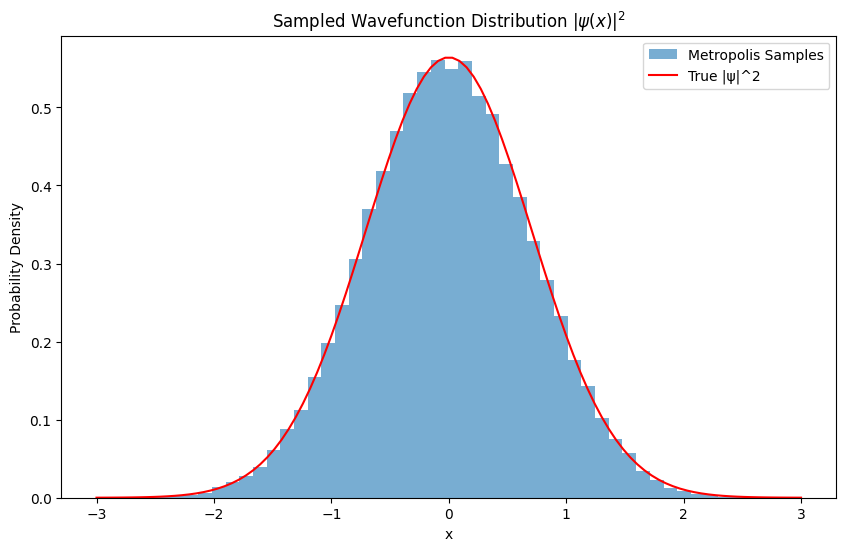

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Trial Wavefunction (Gaussian)
def trial_wavefunction(x, alpha):
    """Gaussian wave function: psi(x) = exp(-alpha * x^2 / 2)"""
    return np.exp(-0.5 * alpha * x**2)

# 2. Local Energy Calculation (H*psi / psi)
def local_energy(x, alpha):
    """Local energy for 1D Harmonic Oscillator: E_L = -1/2 * d^2psi/dx^2 / psi + 1/2 * x^2"""
    return 0.5 * x**2 + 0.5 * alpha * (1 - alpha * x**2)

# 3. Metropolis Algorithm to Sample Probability Density
def metropolis_sampling(num_samples, alpha, step_size=0.5):
    """Generates samples based on the probability distribution |psi|^2"""
    samples = []
    x = 0.0  # Initial position
    
    for _ in range(num_samples):
        x_new = x + np.random.uniform(-step_size, step_size)
        # Metropolis acceptance criterion: psi^2 is proportional to exp(-alpha * x^2)
        if np.random.rand() < np.exp(-alpha * x_new**2) / np.exp(-alpha * x**2):
            x = x_new
        samples.append(x)
    return np.array(samples)

# 4. Monte Carlo Simulation Parameters
num_samples = 100000
alpha = 1.0  # Variational parameter (width of Gaussian)

# Run Sampling
samples = metropolis_sampling(num_samples, alpha)

# Calculate Energy Expectation
energies = local_energy(samples, alpha)
mean_energy = np.mean(energies)
energy_std = np.std(energies) / np.sqrt(num_samples)

print(f"Estimated Ground State Energy: {mean_energy:.5f} +/- {energy_std:.5f}")
print("Analytical Solution: 0.50000")

# 5. Visualization
plt.figure(figsize=(10, 6))
plt.hist(samples, bins=50, density=True, alpha=0.6, label='Metropolis Samples')
x_plot = np.linspace(-3, 3, 100)
plt.plot(x_plot, np.exp(-alpha * x_plot**2) / np.sqrt(np.pi / alpha), 'r', label='True |ψ|^2')
plt.title(r'Sampled Wavefunction Distribution $|\psi(x)|^2$')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.show()


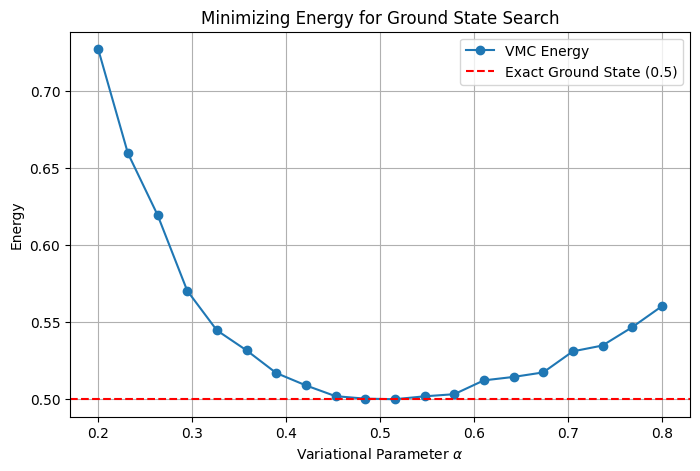

Minimum Energy found at alpha = 0.516


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Hamiltonian & Trial Wavefunction Constants
def local_energy(x, alpha):
    """Local energy for H = -1/2 d^2/dx^2 + 1/2 x^2"""
    # E_loc = (H * psi) / psi
    return alpha + x**2 * (0.5 - 2 * alpha**2)

# 2. Monte Carlo Sampling
def get_energy_estimate(alpha, steps=50000):
    x = 0.0
    delta = 1.0
    energies = []
    
    for _ in range(steps):
        x_new = x + np.random.uniform(-delta, delta)
        # Acceptance ratio for |psi|^2 proportional to exp(-2 * alpha * x^2)
        ratio = np.exp(-2 * alpha * (x_new**2 - x**2))
        
        if np.random.rand() < ratio:
            x = x_new
        
        energies.append(local_energy(x, alpha))
    
    return np.mean(energies)

# 3. Variational Search
alpha_space = np.linspace(0.2, 0.8, 20)
results = [get_energy_estimate(a) for a in alpha_space]

# 4. Plotting the Variational Principle
plt.figure(figsize=(8, 5))
plt.plot(alpha_space, results, 'o-', label='VMC Energy')
plt.axhline(0.5, color='r', linestyle='--', label='Exact Ground State (0.5)')
plt.xlabel(r'Variational Parameter $\alpha$')
plt.ylabel('Energy')
plt.title('Minimizing Energy for Ground State Search')
plt.legend()
plt.grid(True)
plt.show()

print(f"Minimum Energy found at alpha = {alpha_space[np.argmin(results)]:.3f}")


In [ ]:
import periodictable
# Example: Get details for Gold (Au)
element = periodictable.elements[79]
print(f"Name: {element.name}, Symbol: {element.symbol}, Mass: {element.mass}")

In [6]:

import pandas as pd

# Load PubChem data (direct CSV download link)
url = "https://pubchem.ncbi.nlm.nih.gov/rest/pug/periodictable/CSV?response_type=display"
df = pd.read_csv(url)

# 2. Display the entire DataFrame
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df)

,AtomicNumber,Symbol,Name,AtomicMass,CPKHexColor,ElectronConfiguration,Electronegativity,AtomicRadius,IonizationEnergy,ElectronAffinity,OxidationStates,StandardState,MeltingPoint,BoilingPoint,Density,GroupBlock,YearDiscovered
0,1,H,Hydrogen,1.008000,FFFFFF,1s1,2.20,120.0,13.598,0.754,"+1, -1",Gas,13.810,20.28,0.000090,Nonmetal,1766
1,2,He,Helium,4.002600,D9FFFF,1s2,NaN,140.0,24.587,NaN,0,Gas,0.950,4.22,0.000179,Noble gas,1868
2,3,Li,Lithium,7.000000,CC80FF,[He]2s1,0.98,182.0,5.392,0.618,+1,Solid,453.650,1615.00,0.534000,Alkali metal,1817
3,4,Be,Beryllium,9.012183,C2FF00,[He]2s2,1.57,153.0,9.323,NaN,+2,Solid,1560.000,2744.00,1.850000,Alkaline earth metal,1798
4,5,B,Boron,10.810000,FFB5B5,[He]2s2 2p1,2.04,192.0,8.298,0.277,+3,Solid,2348.000,4273.00,2.370000,Metalloid,1808
5,6,C,Carbon,12.011000,909090,[He]2s2 2p2,2.55,170.0,11.260,1.263,"+4, +2, -4",Solid,3823.000,4098.00,2.267000,Nonmetal,Ancient
6,7,N,Nitrogen,14.007000,3050F8,[He] 2s2 2p3,3.04,155.0,14.534,NaN,"+5, +4, +3, +2, +1, -1, -2, -3",Gas,63.150,77.36,0.001251,Nonmetal,1772
7,8,O,Oxygen,15.999000,FF0D0D,[He]2s2 2p4,3.44,152.0,13.618,1.461,-2,Gas,54.360,90.20,0.001429,Nonmetal,1774
8,9,F,Fluorine,18.998403,90E050,[He]2s2 2p5,3.98,135.0,17.423,3.339,-1,Gas,53.530,85.03,0.001696,Halogen,1670
9,10,Ne,Neon,20.180000,B3E3F5,[He]2s2 2p6,NaN,154.0,21.565,NaN,0,Gas,24.560,27.07,0.000900,Noble gas,1898


In [7]:

from IPython.display import HTML

def display_hex(hex_code):
    return HTML(f'<div style="width:50px; height:50px; background-color:{hex_code}; border:1px solid #000;"></div>')

# Example usage
display_hex("#FFFFFF")

# Sample Practice

$\frac{\frac{\sin a}{\cos a} + \frac{\sin b}{\cos b}}{1 - \frac{\sin a \sin b}{\cos a \cos b}}$

$\hbar$

$\frac{5 - \frac{1}{x}}{4}$

$L^\angle$

$\langle \psi_n \lambda$, $\frac{d \hat{H}(\lambda)} {d \lambda}$ $\psi_n$  $\lambda$ $\rangle$

 V  =  range  $P_u$ $\oplus$  null $P_u$

**p** p

$\hat{\mathbf a}$ $\hat{b}$ **a** 

$\hat{P}$

$\sum_p$

$ \frac{4260, \frac{\text{min}}{\text{year}}} {60}$

$ \frac{1/4 \Gamma^2} {(\mathbf E - \mathbf E_\alpha)2 + \frac{1}{4} \Gamma^2}$

V $\nu$ v

$ (\cos \theta - \cos \theta')$

$ \dot \psi$

$ \tilde \psi$

In [1]:
number = -8
root = pow(number, 1/3)
print(root)  # Output: Complex number 

(1.0000000000000002+1.7320508075688772j)


In [2]:
import math

number = -8
root = math.cbrt(number)
print(root)  # Output: -2.0

-2.0


In [3]:
import numpy as np

arr = np.array([8, 27, 64])
roots = np.cbrt(arr)
print(roots)  # Output: [2. 3. 4.]

[2. 3. 4.]


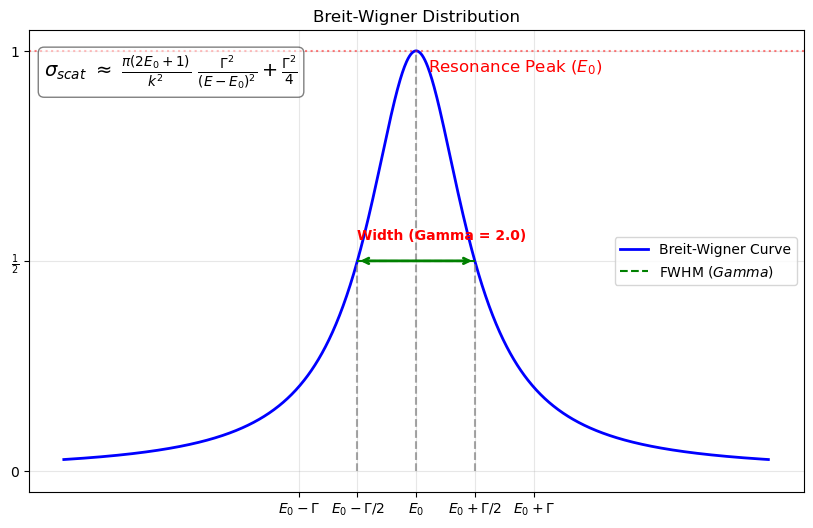

In [16]:
import numpy as np
import matplotlib.pyplot as plt

E0, Gamma = 10.0, 2.0
E = np.linspace(E0 - 3*Gamma, E0 + 3*Gamma, 1000)
BW = (Gamma / 2)**2 / ((E - E0)**2 + (Gamma / 2)**2)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(E, BW, color='blue', label='Breit-Wigner Curve', linewidth=2)



ax.text(0.02, 0.95, 
        r'$\sigma_{scat}$ $\approx$ $\frac{\pi(2 E_0 + 1)}{k^2}$ $\frac{\Gamma^2}{(E-E_0)^2}+ \frac{\Gamma^2}{4}$', 
        transform=ax.transAxes, 
        fontsize=14, 
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5)) 
# ---------------------------------------

# ADDING LABELS INSIDE THE PLOT

plt.text(E0 + 0.2, 0.95, "Resonance Peak ($E_0$)", color='red', fontsize=12)
plt.text(E0 - Gamma/2, 0.55, f"Width (Gamma = {Gamma})", color='red', fontweight='bold')




#ADD DASHED LINES
# Stop the lines at y=1.0 for the peak and y=0.5 for the half-widths
ax.vlines(x=[E0 - Gamma/2, E0, E0 + Gamma/2], 
          ymin=0, 
          ymax=[0.5, 1.0, 0.5], 
          color='gray', 
          linestyle='--', 
          alpha=0.7)

#ADD HORIZONTAL LINES AT Y = 1 AND Y = 1/2

ax.axhline(y=1.0, color='red', linestyle=':', alpha=0.5)



# ADD HORIZONTAL ARROW FOR GAMMA
# This draws a double-headed arrow at y=0.5
ax.annotate('', xy=(E0 - Gamma/2, 0.5), xytext=(E0 + Gamma/2, 0.5),
            arrowprops=dict(arrowstyle='<->', color='green', lw=2))


# Add dashed lines to highlight the peak and width

plt.hlines(0.5, E0 - Gamma/2, E0 + Gamma/2, colors='green', linestyles='--', label='FWHM ($Gamma$)')

# XTICKS
#SET Y-AXIS TICKS AND LABELS

ax.set_yticks([0.0, 0.5, 1.0])
ax.set_yticklabels(['0', r'$\frac{1}{2}$', '1'])

tick_positions = [E0 - Gamma, E0 - Gamma/2, E0, E0 + Gamma/2, E0 + Gamma]
tick_labels = [r'$E_0-\Gamma$', r'$E_0-\Gamma/2$', r'$E_0$', r'$E_0+\Gamma/2$', r'$E_0+\Gamma$']
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)

ax.set_title("Breit-Wigner Distribution")
ax.grid(True, alpha=0.3)

plt.legend()

plt.show()


#  List of experiments

Davisson-Germer  
Photo-electric effect  
Youngs double-slit  
Stern-Gerlach  
EPR   
Badurek-Rauch-Tuppinger  
SQUID(A Superconducting Quantum Interference Device (SQUID) experiment, measures extremely weak magnetic fields by exploiting Josephson junctions, and magnetic flux quantization within a superconducting loop,
cooled by liquid nitrogen at $77^\circ$K or $-196.1^\circ$C.)  
Delayed-choice  



# References

1. Quantum Theory volumes I-III - David Robert Bates
2. Quantum Theory for Mathematicians - Brian C. Hall  
3. Notes from Sidney Coleman's Physics 253a - Sidney Coleman$^*$
4. Courant & Hilbert: Methods of Mathematical Physics volumes I and II - R. Courant and D. Hilbert
5. An introduction to Quantum Optics - Gilbert Grynberg, Alain Aspect, and Claude Fabre
6. Methods of Modern Mathematical Physics volumes I-IV - Michael Reed, and Barry Simon
7. Mathematics for Engineers:Numerics - Gerd Baumann
9. Functional Analysis - K$\dot {o}$saku Yosida  
10. Calculus volumes I-III - Edwin "Jed" Herman and Gilbert Strang  
11. Mathematical foundations of Quantum Mechanics - George W. Mackey
12. The Feynmann lectures on Physics - R.P.Feynman, R.B.Leighton, and M.Sands 
13. Essential Calculus skills practice workbook with full solutions - Chris McMullen
14. Applied partial differential equations - Richard Haberman
15. Physics for Scientists and Engineers - Paul A. Tipler, Gene Mosca
16. Understanding Quantum Mechanics - Roland Omn$\acute{e}$s
17. A course of modern analysis - E.T.Whittaker, and G.N.Watson
18. Handbook of Mathematical Functions; With formulas, Graphs, and Mathematical Tables - Milton Abramowitz, and Irene A. Stegun 
19. Quantum Mechanics; Non-relativistic Theory(Volume 3) - Lev Landau, Evgeny Lifshitz, Vladimir Berestetskii, and Lev Pitaevsk
20. Quantum Mechanics - Lecture notes for PHYS223 - Henning Schomerus
21. Zaarur E Schaum's outline of Quantum Mechanics including hundred of solved problems
22. Pauli and the Spin-Statistics Theorem - Ian Duck, and E.C.G.Sudarshan
23. Lectures on Quantum Mechanics - Dirac Paul A.M.
24. Introduction to Linear Algebra - Gilbert Strang
25. Quantum Mechanics_Concepts and Applications - Nouredine Zettili
26. Riemannian Geometry and Geometric Analsysis - J$\ddot{u}gen$ Jost  
27. Lectures on Quantum Mechanics - Steven Weinberg
